# Case 1 Tennessee data centre geo-grouping, characteristic clustering and manual analysis

This Notebook also retains three complementary calibres:

1. **Confird baseline**: 60 identified and identifiable Masters describing the geographical pattern of existing facilities;
2. **Expanded cohort**: 75 unique locations describing the distribution of projects formed by Master and Candidate;
3. **Feature-space clearing**: Identification of similar site environments with complete numerical external environmental characteristics.

Geographical cluster uses Haversine distance from DBSCAN. `log1p` for non-negative variables; then standardize with `RobustScaler`; the K value is selected in 2-8 by Silhouette score. Candidate identifies the results separately and does not double-count shared or associated physical locations.

In [17]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import haversine_distances
from sklearn.preprocessing import RobustScaler
from IPython.display import display, Markdown

EARTH_KM = 6371.0088
RANDOM_STATE = 4701

def distance_km(points):
    return haversine_distances(np.radians(np.asarray(points, dtype=float))) * EARTH_KM

def cluster(points, eps_km=20, min_samples=3, weights=None):
    return DBSCAN(eps=eps_km, min_samples=min_samples, metric='precomputed').fit_predict(
        distance_km(points), sample_weight=weights
    )

def pair_jaccard(a, b):
    a, b = np.asarray(a), np.asarray(b)
    upper = np.triu(np.ones((len(a), len(a)), dtype=bool), 1)
    pa = (a[:, None] == a[None, :]) & (a[:, None] >= 0) & upper
    pb = (b[:, None] == b[None, :]) & (b[:, None] >= 0) & upper
    union = (pa | pb).sum()
    return float((pa & pb).sum() / union) if union else float('nan')

def named_dbscan(frame, raw_col, prefix='C'):
    clustered = frame[frame[raw_col] >= 0]
    centroids = clustered.groupby(raw_col)[['longitude', 'latitude']].mean().sort_values('longitude')
    order = {raw: i + 1 for i, raw in enumerate(centroids.index)}
    city_mode = clustered.groupby(raw_col)['city'].agg(lambda x: x.dropna().value_counts().index[0] if x.notna().any() else 'TN')
    names = {raw: f'{prefix}{order[raw]} {city_mode[raw]} area' for raw in order}
    return frame[raw_col].map(names).fillna('Noise / isolated'), centroids, names

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#7A5195', '#2F4B7C']
HERE = Path.cwd()
SOURCE_XLSX = (HERE / '../../dataset/tennessee_public_data_centers.xlsx').resolve()
STATE_GEOJSON = (HERE / '../../../principal_factor/data set/data/figure/us_states_2025.geojson').resolve()
RESULTS = HERE / 'results'
FIGURES = RESULTS / 'figures'
FEATURE_MATRIX = RESULTS / 'site_feature_matrix.csv'
FIGURES.mkdir(parents=True, exist_ok=True)
print('Source workbook:', SOURCE_XLSX)
print('Feature matrix:', FEATURE_MATRIX.resolve())
print('Results directory:', RESULTS.resolve())

Source workbook: /Users/steve/Project/UTK/outputs/Data center/TN/dataset/tennessee_public_data_centers.xlsx
Feature matrix: /Users/steve/Project/UTK/outputs/Data center/TN/model/phase 1/results/site_feature_matrix.csv
Results directory: /Users/steve/Project/UTK/outputs/Data center/TN/model/phase 1/results


## 1 Data access and analysis cohort

The workbook is used to define 60 jobs. The extension analysis directly reads the already heavy 75 rows `site_feature_matrix.csv`, so the shared location and associated Master Candidate do not recur. Field integrity and project recognition are two different things, and `record_role` is kept in all charts for comparison.

,cohort,count
0,Master workbook,61
1,Confirmed mappable Master baseline,60
2,Unique Candidate locations,14
3,Unconfirmed Master location,1
4,Expanded unique locations,75


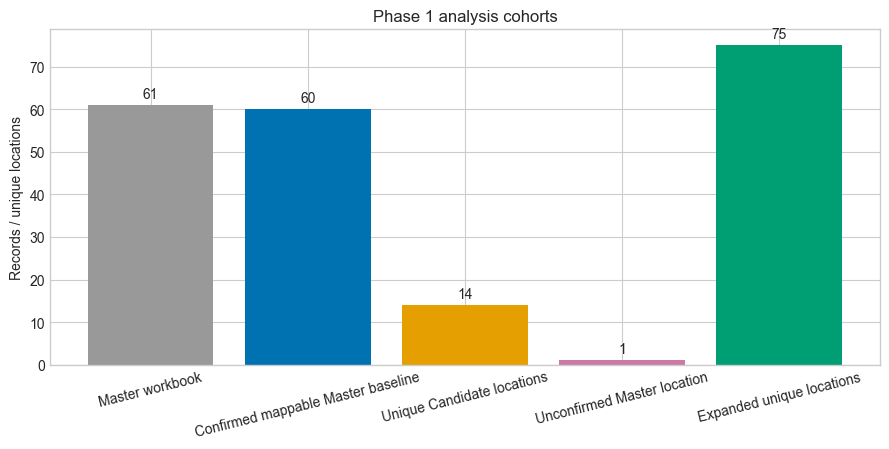

In [18]:
master = pd.read_excel(SOURCE_XLSX, sheet_name='Master')
confirmed = master.loc[
    master['latitude'].notna() & master['longitude'].notna() &
    master['analysis_scope'].ne('unconfirmed_candidate')
].copy()
confirmed['record_id'] = confirmed['facility_id']
confirmed['record_role'] = 'confirmed_master'

expanded = pd.read_csv(FEATURE_MATRIX)
expanded['record_id'] = expanded['facility_id']
expanded['record_role'] = np.select(
    [expanded['facility_id'].str.startswith('TNCAND-'), expanded['analysis_scope'].eq('unconfirmed_candidate')],
    ['candidate', 'unconfirmed_master'],
    default='confirmed_master'
)

baseline_ids = set(confirmed['facility_id'])
expanded_baseline = expanded[expanded['facility_id'].isin(baseline_ids)].copy()

audit = pd.DataFrame({
    'cohort': ['Master workbook', 'Confirmed mappable Master baseline', 'Unique Candidate locations',
               'Unconfirmed Master location', 'Expanded unique locations'],
    'count': [len(master), len(confirmed), expanded.record_role.eq('candidate').sum(),
              expanded.record_role.eq('unconfirmed_master').sum(), len(expanded)]
})
display(audit)

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(audit['cohort'], audit['count'], color=['#999999', '#0072B2', '#E69F00', '#CC79A7', '#009E73'])
ax.bar_label(bars, padding=3)
ax.set_ylabel('Records / unique locations')
ax.set_title('Phase 1 analysis cohorts')
ax.tick_params(axis='x', rotation=14)
fig.tight_layout()
fig.savefig(FIGURES / '01_cohort_counts.png', dpi=180)
plt.show()

assert len(confirmed) == 60
assert len(expanded) == 75 and expanded.facility_id.is_unique
assert set(confirmed.facility_id) <= set(expanded.facility_id)

## 2 State-level distribution versus nearest neighbour scale

Recent Neighbourhood Distribution helps to determine the range at which “local groups” are suitable for observation. It does not automatically determine the only correct `eps` and therefore reports the full parameter grid later.

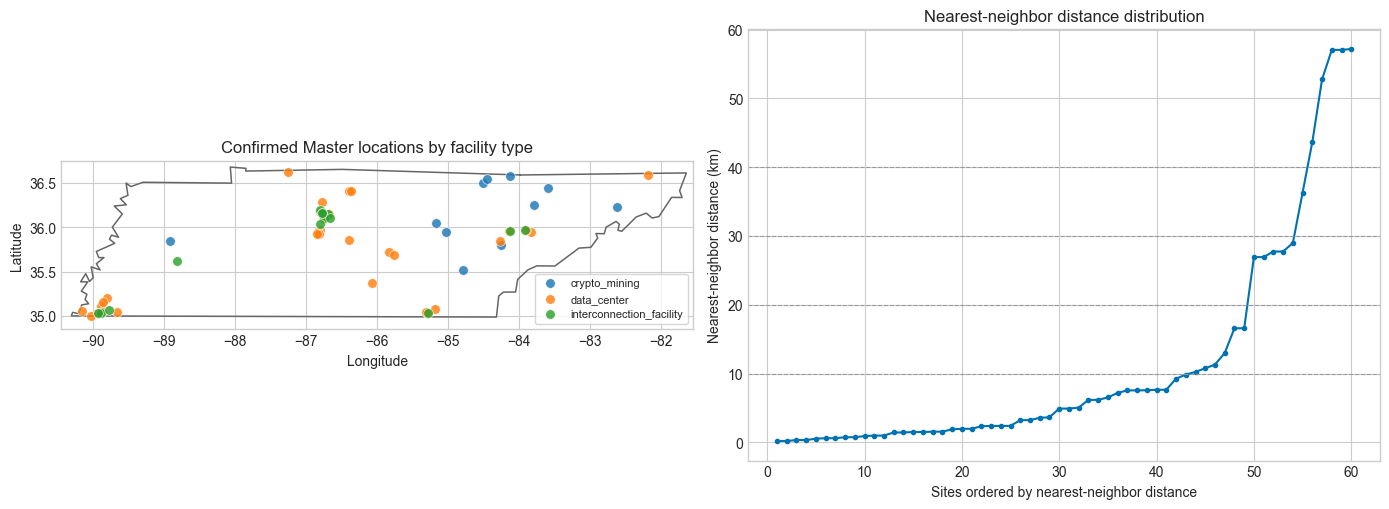

,nearest_neighbor_km
count,60.00
mean,11.07
std,15.48
min,0.21
25%,1.51
50%,4.92
75%,10.91
90%,29.73
max,57.17


In [19]:
state = json.loads(STATE_GEOJSON.read_text())
tn = next(f for f in state['features'] if f['properties'].get('STUSAB') == 'TN')

def polygon_rings(geometry):
    coords = geometry['coordinates']
    polygons = coords if geometry['type'] == 'MultiPolygon' else [coords]
    for polygon in polygons:
        yield np.asarray(polygon[0])

def draw_tn(ax, color='#666666', lw=1.1):
    for ring in polygon_rings(tn['geometry']):
        ax.plot(ring[:,0], ring[:,1], color=color, lw=lw, zorder=1)
    ax.set_xlim(-90.45,-81.55); ax.set_ylim(34.85,36.75)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect(1.25)

xy = confirmed[['latitude','longitude']].to_numpy()
D = distance_km(xy); np.fill_diagonal(D, np.inf)
confirmed['nearest_neighbor_km'] = D.min(axis=1)

fig, axes = plt.subplots(1,2,figsize=(14,5.2))
draw_tn(axes[0]);
for typ, grp in confirmed.groupby('facility_type'):
    axes[0].scatter(grp.longitude, grp.latitude, s=48, alpha=.82, label=typ, edgecolor='white', linewidth=.5)
axes[0].legend(frameon=True, fontsize=8); axes[0].set_title('Confirmed Master locations by facility type')
v = np.sort(confirmed['nearest_neighbor_km'])
axes[1].plot(np.arange(1,len(v)+1),v,marker='o',ms=3,color='#0072B2')
for y in [10,20,30,40]: axes[1].axhline(y,color='#999999',lw=.8,ls='--')
axes[1].set(xlabel='Sites ordered by nearest-neighbor distance',ylabel='Nearest-neighbor distance (km)',title='Nearest-neighbor distance distribution')
fig.tight_layout(); fig.savefig(FIGURES/'02_statewide_and_nearest_neighbor.png',dpi=180); plt.show()
display(confirmed['nearest_neighbor_km'].describe(percentiles=[.25,.5,.75,.9]).to_frame().round(2))

## 3 DBSCAN Parameter Scan

DBSCAN identifies at least `min_samples` adjacent areas as clusters and the rest of the records remain noise. Scan 5-60 km shows the scale at which clusters appear, merge and absorb isolated points.

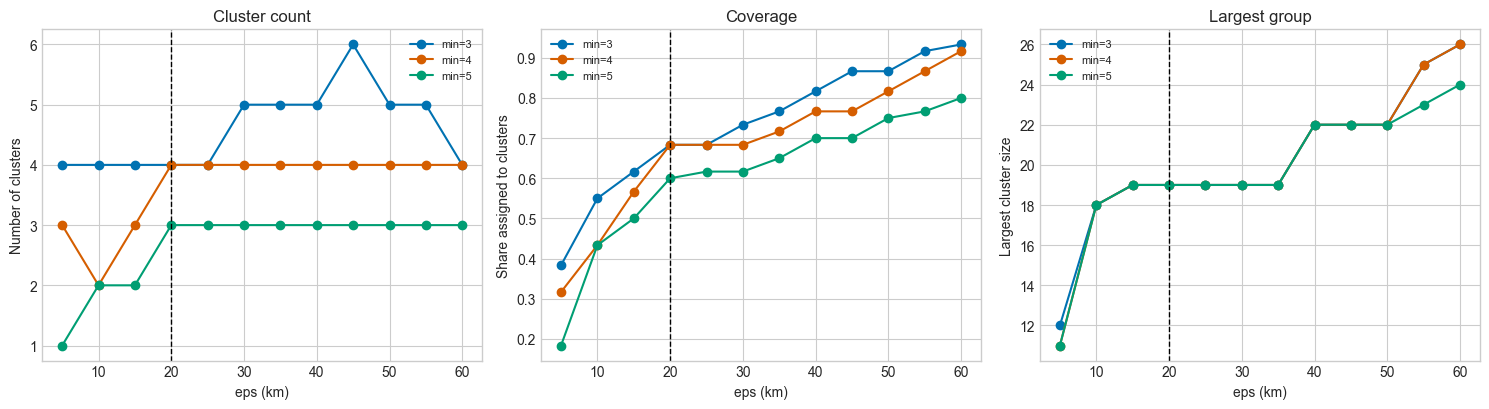

clusters           clustered_share            
min_samples        3    4    5               3     4     5
eps_km                                                    
5                4.0  3.0  1.0            0.38  0.32  0.18
10               4.0  2.0  2.0            0.55  0.43  0.43
15               4.0  3.0  2.0            0.62  0.57  0.50
20               4.0  4.0  3.0            0.68  0.68  0.60
25               4.0  4.0  3.0            0.68  0.68  0.62
30               5.0  4.0  3.0            0.73  0.68  0.62
35               5.0  4.0  3.0            0.77  0.72  0.65
40               5.0  4.0  3.0            0.82  0.77  0.70
45               6.0  4.0  3.0            0.87  0.77  0.70
50               5.0  4.0  3.0            0.87  0.82  0.75
55               5.0  4.0  3.0            0.92  0.87  0.77
60               4.0  4.0  3.0            0.93  0.92  0.80

In [20]:
eps_values = np.arange(5,65,5)
min_values = [3,4,5]
rows=[]; label_bank={}
for m in min_values:
    for e in eps_values:
        lab=cluster(xy,e,m); label_bank[(e,m)]=lab
        rows.append({'eps_km':e,'min_samples':m,'clusters':len(set(lab)-{-1}),
                     'clustered_share':(lab>=0).mean(),'noise_share':(lab<0).mean(),
                     'largest_cluster':max(pd.Series(lab[lab>=0]).value_counts(),default=0)})
sweep=pd.DataFrame(rows)

fig, axes=plt.subplots(1,3,figsize=(15,4.2))
for m,c in zip(min_values,COLORS):
    q=sweep[sweep.min_samples==m]
    axes[0].plot(q.eps_km,q.clusters,marker='o',label=f'min={m}',color=c)
    axes[1].plot(q.eps_km,q.clustered_share,marker='o',label=f'min={m}',color=c)
    axes[2].plot(q.eps_km,q.largest_cluster,marker='o',label=f'min={m}',color=c)
axes[0].set(ylabel='Number of clusters'); axes[1].set(ylabel='Share assigned to clusters'); axes[2].set(ylabel='Largest cluster size')
for ax in axes:
    ax.axvline(20,color='black',ls='--',lw=1); ax.set_xlabel('eps (km)'); ax.legend(fontsize=8)
axes[0].set_title('Cluster count'); axes[1].set_title('Coverage'); axes[2].set_title('Largest group')
fig.tight_layout(); fig.savefig(FIGURES/'03_parameter_sweep.png',dpi=180); plt.show()
display(sweep.pivot(index='eps_km',columns='min_samples',values=['clusters','clustered_share']).round(2))

## 4 Maps at different scales

Three maps show changes in systems from the urban core to wider regions. The continuous distance chain may allow the DBSCAN cluster to be merged, so the larger ZXPROTOZX should be understood as a regional network rather than a single park.

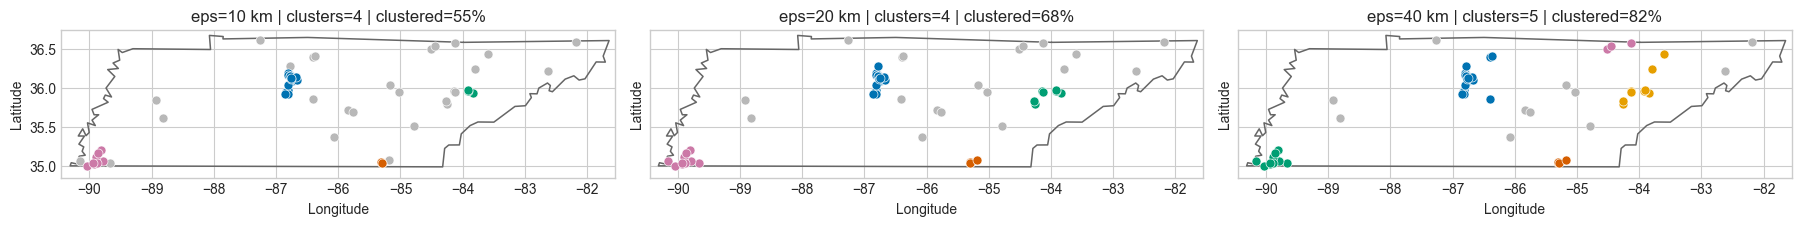

In [21]:
fig, axes=plt.subplots(1,3,figsize=(18,5.1),sharex=True,sharey=True)
for ax,e in zip(axes,[10,20,40]):
    lab=label_bank[(e,3)]; draw_tn(ax)
    for k in sorted(set(lab)):
        idx=lab==k; color='#B8B8B8' if k==-1 else COLORS[k%len(COLORS)]
        ax.scatter(confirmed.loc[idx,'longitude'],confirmed.loc[idx,'latitude'],s=42,color=color,edgecolor='white',linewidth=.45)
    ax.set_title(f'eps={e} km | clusters={len(set(lab)-{-1})} | clustered={(lab>=0).mean():.0%}')
fig.tight_layout(); fig.savefig(FIGURES/'04_scale_comparison_maps.png',dpi=180); plt.show()

## 5 Main display of calibres and group names

Cluster names come from the most common cities in the group and are used only for readability; they are not formal market delimitations.

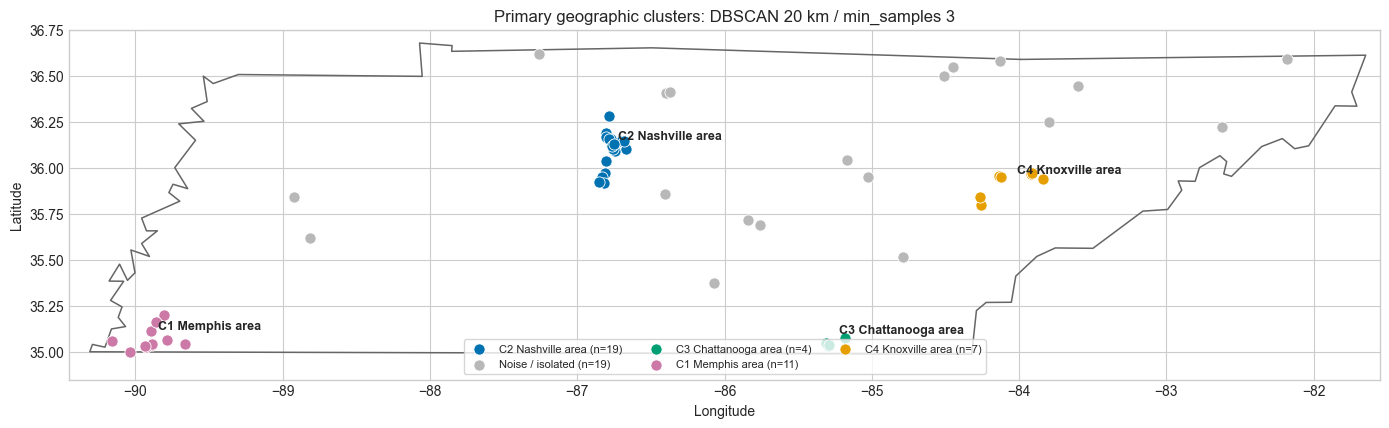

24690

In [22]:
primary=cluster(xy,20,3)
confirmed['cluster_raw']=primary
centroids=(confirmed[confirmed.cluster_raw>=0].groupby('cluster_raw')[['longitude','latitude']].mean().sort_values('longitude'))
order={raw:i+1 for i,raw in enumerate(centroids.index)}
city_mode=confirmed[confirmed.cluster_raw>=0].groupby('cluster_raw')['city'].agg(lambda x:x.value_counts().index[0])
names={raw:f"C{order[raw]} {city_mode[raw]} area" for raw in order}
confirmed['cluster']=confirmed.cluster_raw.map(names).fillna('Noise / isolated')

fig,ax=plt.subplots(figsize=(14,6.2));draw_tn(ax)
for i,(name,g) in enumerate(confirmed.groupby('cluster',sort=False)):
    color='#B8B8B8' if name=='Noise / isolated' else COLORS[i%len(COLORS)]
    ax.scatter(g.longitude,g.latitude,s=65,color=color,label=f'{name} (n={len(g)})',edgecolor='white',linewidth=.6,zorder=3)
for raw,row in centroids.iterrows():
    ax.annotate(names[raw],(row.longitude,row.latitude),xytext=(5,7),textcoords='offset points',fontsize=9,weight='bold')
ax.legend(loc='lower center',ncol=3,fontsize=8,frameon=True);ax.set_title('Primary geographic clusters: DBSCAN 20 km / min_samples 3')
fig.tight_layout();fig.savefig(FIGURES/'05_primary_clusters.png',dpi=200);plt.show()

map_fields=['facility_id','facility_name','city','facility_type','status_normalized','operator',
            'location_precision','longitude','latitude','cluster']
map_records=confirmed[map_fields].where(pd.notna(confirmed[map_fields]),None).to_dict('records')
state_rings=[ring.tolist() for ring in polygon_rings(tn['geometry'])]
cluster_colors={name:('#9AA0A6' if name=='Noise / isolated' else COLORS[i%len(COLORS)])
                for i,name in enumerate(confirmed['cluster'].drop_duplicates())}

# Native SVG is intentionally used here. The HTML has no CDN, map tiles, Plotly runtime,
# or external CSV dependency, so it also renders when opened directly with file://.
html_doc='''<!doctype html><html><head><meta charset="utf-8"><title>TN DC clusters</title>
<style>body{font-family:system-ui,sans-serif;margin:0;background:#f5f7fa;color:#17212b}.wrap{max-width:1220px;margin:auto;padding:18px}
.card{background:white;border:1px solid #d7dde5;border-radius:12px;box-shadow:0 2px 10px #0001;padding:14px}.bar{display:flex;gap:12px;flex-wrap:wrap;align-items:center;margin:8px 0 12px}
button,label{font-size:14px}button{padding:6px 10px;border:1px solid #b8c2cc;border-radius:7px;background:white;cursor:pointer}
svg{width:100%;height:auto;background:#eef3f7;border-radius:8px;border:1px solid #ccd4dc}.state{fill:#fbfcfd;stroke:#46535f;stroke-width:1.8}.pt{stroke:white;stroke-width:1.2;cursor:pointer}.pt:hover{stroke:#111;stroke-width:2.4}
#detail{min-height:48px;padding:9px 4px 0;font-size:14px}.muted{color:#66717d;font-size:13px}</style></head>
<body><div class="wrap"><h2>Tennessee data-center geographic clusters</h2><div class="muted">DBSCAN: 20 km, min_samples = 3. Hover for a short label; click a point for full details. Wheel to zoom and drag to pan.</div>
<div class="card"><div id="filters" class="bar"></div><svg id="map" viewBox="0 0 1100 500" role="img" aria-label="Tennessee data-center cluster map"></svg><div id="detail">Select a point.</div></div></div>
<script>const sites=__DATA__;const rings=__RINGS__;const colors=__COLORS__;
const svg=document.getElementById('map'),NS='http://www.w3.org/2000/svg',W=1100,H=500,pad=35,b=[-90.45,-81.55,34.85,36.75];
const X=x=>pad+(x-b[0])/(b[1]-b[0])*(W-2*pad),Y=y=>H-pad-(y-b[2])/(b[3]-b[2])*(H-2*pad);
function el(n,a,p=svg){const e=document.createElementNS(NS,n);for(const[k,v]of Object.entries(a||{}))e.setAttribute(k,v);p.appendChild(e);return e}
for(const r of rings)el('path',{class:'state',d:r.map((q,i)=>(i?'L':'M')+X(q[0]).toFixed(1)+','+Y(q[1]).toFixed(1)).join(' ')+' Z'});
const groups=[...new Set(sites.map(d=>d.cluster))];const filters=document.getElementById('filters');
for(const g of groups){const lab=document.createElement('label');const cb=document.createElement('input');cb.type='checkbox';cb.checked=true;cb.dataset.group=g;cb.onchange=apply;lab.append(cb,document.createTextNode(' '+g+' '));lab.style.color=colors[g];filters.appendChild(lab)}
const reset=document.createElement('button');reset.textContent='Reset view';reset.onclick=()=>svg.setAttribute('viewBox','0 0 1100 500');filters.appendChild(reset);
for(const d of sites){const c=el('circle',{class:'pt',cx:X(d.longitude),cy:Y(d.latitude),r:6.5,fill:colors[d.cluster],'data-group':d.cluster,tabindex:0});const t=el('title',{},c);t.textContent=d.facility_name+' — '+d.cluster;c.onclick=()=>{document.getElementById('detail').textContent=[d.facility_name,d.city,d.cluster,d.facility_type,d.status_normalized,d.operator,'precision: '+d.location_precision].filter(Boolean).join(' | ')}}
function apply(){const on=new Set([...document.querySelectorAll('#filters input:checked')].map(x=>x.dataset.group));document.querySelectorAll('.pt').forEach(p=>p.style.display=on.has(p.dataset.group)?'':'none')}
let drag=null;svg.addEventListener('wheel',e=>{e.preventDefault();let v=svg.viewBox.baseVal,f=e.deltaY>0?1.15:.87,cx=v.x+v.width/2,cy=v.y+v.height/2;svg.setAttribute('viewBox',[cx-v.width*f/2,cy-v.height*f/2,v.width*f,v.height*f].join(' '))},{passive:false});
svg.addEventListener('pointerdown',e=>{drag={x:e.clientX,y:e.clientY,v:[svg.viewBox.baseVal.x,svg.viewBox.baseVal.y,svg.viewBox.baseVal.width,svg.viewBox.baseVal.height]};svg.setPointerCapture(e.pointerId)});svg.addEventListener('pointermove',e=>{if(!drag)return;let r=svg.getBoundingClientRect(),dx=(e.clientX-drag.x)*drag.v[2]/r.width,dy=(e.clientY-drag.y)*drag.v[3]/r.height;svg.setAttribute('viewBox',[drag.v[0]-dx,drag.v[1]-dy,drag.v[2],drag.v[3]].join(' '))});svg.addEventListener('pointerup',()=>drag=null);
</script></body></html>'''
html_doc=(html_doc.replace('__DATA__',json.dumps(map_records,ensure_ascii=False))
          .replace('__RINGS__',json.dumps(state_rings))
          .replace('__COLORS__',json.dumps(cluster_colors)))
(RESULTS/'interactive_clusters.html').write_text(html_doc,encoding='utf-8')

Offline interactive map: model/phase 1/results/interactive_clusters.html

## Quantitative comparison of cluster composition

The following indicators are used to support manual reading:

- ** Relative concentration ratio**: the proportion of certain types of facilities in clusters ÷ It is the proportion of all confird Masters. > 1 indicates the relative concentration of the group.
- **Cramér's V**: Overall correlation intensity between groups and category variables, 0 means no observed association, close to 1 means strong association. It's not a causal effect.
- ** Operator HHI**: squared operator share within the same group; higher to indicate that records are concentrated in a few operators.


,cluster,n,centroid_lat,centroid_lon,cities,operators,operator_hhi,core_share,operational_share,median_nn_km
0,C1 Memphis area,11,35.071,-89.895,2,10,0.107,1.000,0.727,6.184
1,C2 Nashville area,19,36.101,-86.773,3,14,0.080,1.000,0.842,1.976
2,C3 Chattanooga area,4,35.049,-85.271,1,4,0.250,1.000,0.750,1.330
3,C4 Knoxville area,7,35.918,-84.065,2,7,0.143,0.857,1.000,1.445


,variable,cramers_v
0,facility_type,0.0
1,status_normalized,0.0
2,location_precision,0.0


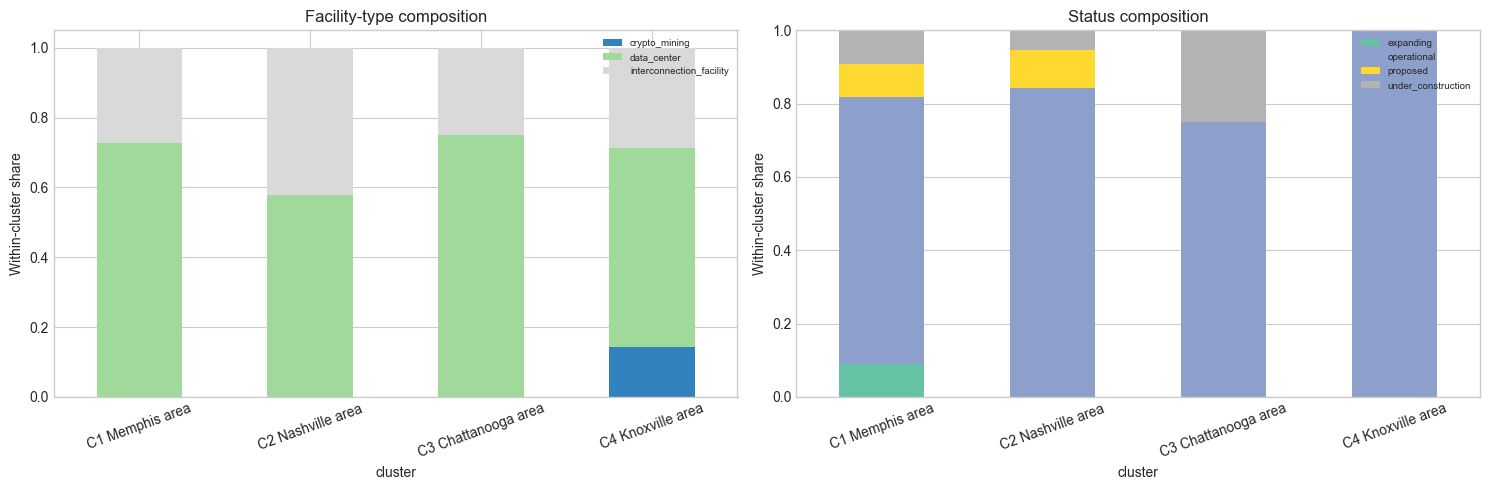

In [23]:
clustered=confirmed[confirmed.cluster_raw>=0].copy()

def cramers_v(a,b):
    # Bias-corrected Cramer's V; still interpreted cautiously for sparse tables.
    tab=pd.crosstab(a,b)
    if min(tab.shape)<2: return np.nan
    chi2=chi2_contingency(tab,correction=False)[0]; n=tab.to_numpy().sum(); phi2=chi2/n
    r,k=tab.shape
    phi2corr=max(0,phi2-((k-1)*(r-1))/(n-1))
    rcorr=r-((r-1)**2)/(n-1); kcorr=k-((k-1)**2)/(n-1)
    denom=min(kcorr-1,rcorr-1)
    return np.sqrt(phi2corr/denom) if denom>0 else np.nan

summary=[]
for name,g in clustered.groupby('cluster'):
    shares=g['operator'].fillna('Unknown').value_counts(normalize=True)
    summary.append({'cluster':name,'n':len(g),'centroid_lat':g.latitude.mean(),'centroid_lon':g.longitude.mean(),
                    'cities':g.city.nunique(),'operators':g.operator.nunique(dropna=True),
                    'operator_hhi':(shares**2).sum(),'core_share':g.analysis_scope.eq('core_data_center').mean(),
                    'operational_share':g.status_normalized.eq('operational').mean(),
                    'median_nn_km':g.nearest_neighbor_km.median()})
cluster_summary=pd.DataFrame(summary).sort_values('centroid_lon').reset_index(drop=True)
display(cluster_summary.round(3))

assoc=pd.DataFrame({'variable':['facility_type','status_normalized','location_precision'],
                    'cramers_v':[cramers_v(clustered.cluster,clustered[c]) for c in ['facility_type','status_normalized','location_precision']]})
display(assoc.round(3))

fig,axes=plt.subplots(1,2,figsize=(15,5))
pd.crosstab(clustered.cluster,clustered.facility_type,normalize='index').plot(kind='bar',stacked=True,ax=axes[0],colormap='tab20c')
pd.crosstab(clustered.cluster,clustered.status_normalized,normalize='index').plot(kind='bar',stacked=True,ax=axes[1],colormap='Set2')
for ax,title in zip(axes,['Facility-type composition','Status composition']):
    ax.set_ylabel('Within-cluster share'); ax.set_title(title); ax.legend(fontsize=7); ax.tick_params(axis='x',rotation=20)
fig.tight_layout();fig.savefig(FIGURES/'06_cluster_composition.png',dpi=180);plt.show()

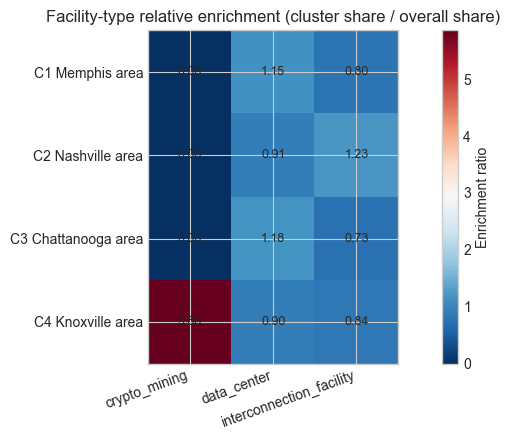

facility_type,crypto_mining,data_center,interconnection_facility
cluster,,,
C1 Memphis area,0.00,1.15,0.80
C2 Nashville area,0.00,0.91,1.23
C3 Chattanooga area,0.00,1.18,0.73
C4 Knoxville area,5.86,0.90,0.84


In [24]:
def enrichment_table(field):
    overall=clustered[field].value_counts(normalize=True)
    within=pd.crosstab(clustered.cluster,clustered[field],normalize='index')
    return within.div(overall,axis=1)

enrich=enrichment_table('facility_type')
fig,ax=plt.subplots(figsize=(9,4.5));
im=ax.imshow(enrich,cmap='RdBu_r',vmin=0,vmax=max(2,float(enrich.max().max())))
ax.set_xticks(range(enrich.shape[1]),enrich.columns,rotation=20,ha='right');ax.set_yticks(range(enrich.shape[0]),enrich.index)
for i in range(enrich.shape[0]):
    for j in range(enrich.shape[1]): ax.text(j,i,f'{enrich.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9)
ax.set_title('Facility-type relative enrichment (cluster share / overall share)');fig.colorbar(im,ax=ax,label='Enrichment ratio')
fig.tight_layout();fig.savefig(FIGURES/'07_facility_enrichment.png',dpi=180);plt.show()
display(enrich.round(2))

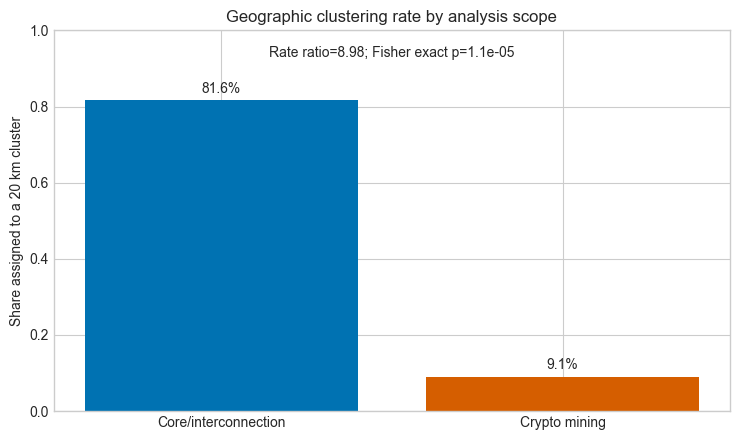

cluster_raw,Clustered,Noise / small group
analysis_scope,,
Core/interconnection,40,9
Crypto mining,1,10


In [25]:
scope_tab=pd.crosstab(confirmed.analysis_scope.eq('core_data_center'),confirmed.cluster_raw.ge(0)).reindex(index=[True,False],columns=[True,False],fill_value=0)
core_cluster_rate=scope_tab.loc[True,True]/scope_tab.loc[True].sum()
crypto_cluster_rate=scope_tab.loc[False,True]/scope_tab.loc[False].sum()
cluster_rate_ratio=core_cluster_rate/crypto_cluster_rate
cluster_odds_ratio,fisher_p=fisher_exact(scope_tab.to_numpy())

rates=pd.Series({'Core/interconnection':core_cluster_rate,'Crypto mining':crypto_cluster_rate})
fig,ax=plt.subplots(figsize=(7.5,4.5));bars=ax.bar(rates.index,rates.values,color=['#0072B2','#D55E00'])
ax.bar_label(bars,labels=[f'{v:.1%}' for v in rates.values],padding=3)
ax.set(ylim=(0,1),ylabel='Share assigned to a 20 km cluster',title='Geographic clustering rate by analysis scope')
ax.text(.5,.93,f'Rate ratio={cluster_rate_ratio:.2f}; Fisher exact p={fisher_p:.2g}',ha='center',transform=ax.transAxes)
fig.tight_layout();fig.savefig(FIGURES/'07b_scope_cluster_membership.png',dpi=180);plt.show()
display(scope_tab.rename(index={True:'Core/interconnection',False:'Crypto mining'},columns={True:'Clustered',False:'Noise / small group'}))

## 7 Sensitivity of stability and record density

When the main result is compared with the different radiuss, the Jaccard similarity of the common grouping points is used; the noise points are not mistaken for a common group. Check also Candidate weighted accessions, retaining only core data center, retaining only more precise coordinates, and 1/3/5 km random coordinate disturbances.


,scenario,pair_jaccard_vs_primary,ARI_vs_primary
0,eps 5 km,0.320,0.290
1,eps 10 km,0.771,0.684
2,eps 15 km,0.929,0.870
3,eps 20 km,1.000,1.000
4,eps 25 km,1.000,1.000
5,eps 30 km,0.988,0.923
6,eps 35 km,0.934,0.853
7,eps 40 km,0.764,0.712
8,eps 45 km,0.757,0.667
9,eps 50 km,0.701,0.651


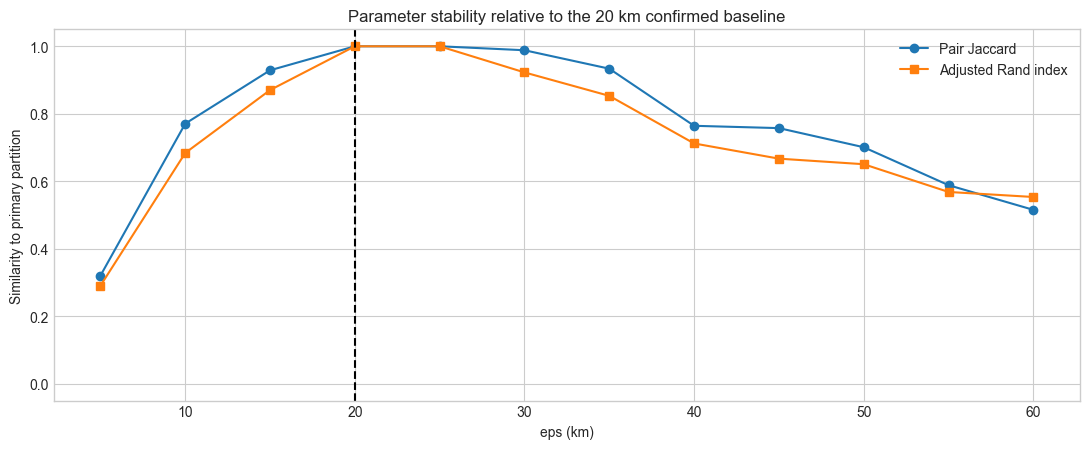

In [26]:
pair_stability = []
for e in eps_values:
    pair_stability.append({
        'scenario': f'eps {e} km',
        'pair_jaccard_vs_primary': pair_jaccard(primary, label_bank[(e, 3)]),
        'ARI_vs_primary': adjusted_rand_score(primary, label_bank[(e, 3)])
    })

expanded_xy = expanded[['latitude', 'longitude']].to_numpy()
expanded_raw = cluster(expanded_xy, 20, 3)
expanded['geo_cluster_raw'] = expanded_raw
expanded['geo_cluster'], expanded_centroids, expanded_names = named_dbscan(expanded, 'geo_cluster_raw', 'E')
expanded_baseline_labels = expanded.set_index('facility_id').loc[confirmed.facility_id, 'geo_cluster_raw'].to_numpy()
pair_stability.append({
    'scenario': 'Expanded 75 unique locations',
    'pair_jaccard_vs_primary': pair_jaccard(primary, expanded_baseline_labels),
    'ARI_vs_primary': adjusted_rand_score(primary, expanded_baseline_labels)
})

def subset_scenario(mask, label):
    idx = np.flatnonzero(mask.to_numpy())
    lab = cluster(xy[idx], 20, 3)
    sub_primary = primary[idx]
    pair_stability.append({
        'scenario': label,
        'pair_jaccard_vs_primary': pair_jaccard(sub_primary, lab),
        'ARI_vs_primary': adjusted_rand_score(sub_primary, lab)
    })

subset_scenario(confirmed.analysis_scope.eq('core_data_center'), 'Core data centers only')
subset_scenario(confirmed.location_precision.isin(['exact', 'address_or_site']), 'Exact/address-site coordinates')
stability = pd.DataFrame(pair_stability)
display(stability.round(3))

fig, ax = plt.subplots(figsize=(11, 4.6))
q = stability[stability.scenario.str.startswith('eps')]
eps_axis = q.scenario.str.extract(r'(\d+)')[0].astype(int)
ax.plot(eps_axis, q.pair_jaccard_vs_primary, marker='o', label='Pair Jaccard')
ax.plot(eps_axis, q.ARI_vs_primary, marker='s', label='Adjusted Rand index')
ax.axvline(20, color='black', ls='--')
ax.set(xlabel='eps (km)', ylabel='Similarity to primary partition', ylim=(-.05, 1.05),
       title='Parameter stability relative to the 20 km confirmed baseline')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / '08_parameter_stability.png', dpi=180)
plt.show()

pair_jaccard             clusters         clustered_share
                  mean    min  max     mean min max            mean
radius_km                                                          
1                1.000  0.953  1.0    4.005   4   5           0.683
3                0.992  0.929  1.0    4.105   4   5           0.681
5                0.990  0.929  1.0    4.130   4   5           0.680

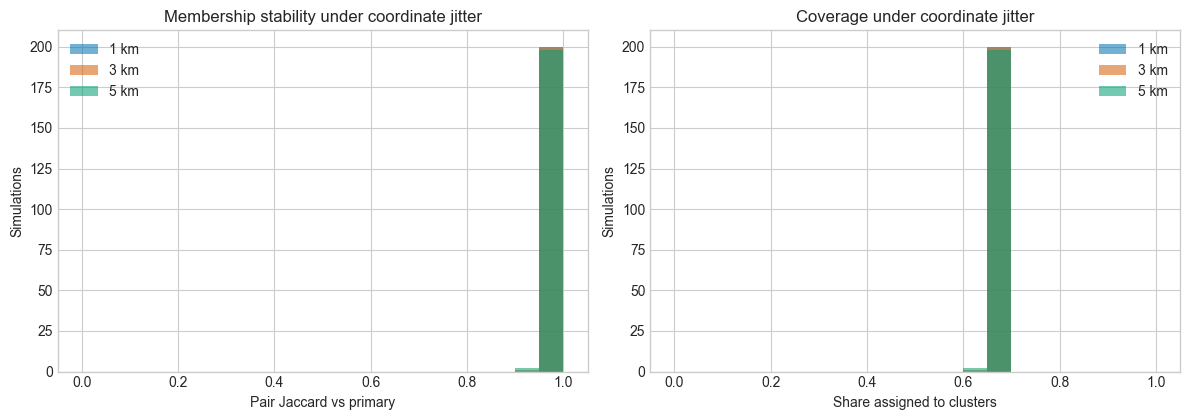

In [27]:
rng=np.random.default_rng(4701)
def jitter_latlon(points,radius_km):
    angle=rng.uniform(0,2*np.pi,len(points)); r=radius_km*np.sqrt(rng.uniform(0,1,len(points)))
    out=points.copy().astype(float)
    out[:,0]+=r*np.sin(angle)/111.1
    out[:,1]+=r*np.cos(angle)/(111.1*np.cos(np.radians(out[:,0])))
    return out

jitter_rows=[]
for radius in [1,3,5]:
    for rep in range(200):
        lab=cluster(jitter_latlon(xy,radius),20,3)
        jitter_rows.append({'radius_km':radius,'rep':rep,'pair_jaccard':pair_jaccard(primary,lab),
                            'clusters':len(set(lab)-{-1}),'clustered_share':(lab>=0).mean()})
jitter=pd.DataFrame(jitter_rows)
display(jitter.groupby('radius_km').agg({'pair_jaccard':['mean','min','max'],'clusters':['mean','min','max'],'clustered_share':'mean'}).round(3))

fig,axes=plt.subplots(1,2,figsize=(12,4.3))
for r,c in zip([1,3,5],COLORS):
    q=jitter[jitter.radius_km==r]
    axes[0].hist(q.pair_jaccard,bins=np.linspace(0,1,21),alpha=.55,label=f'{r} km',color=c)
    axes[1].hist(q.clustered_share,bins=np.linspace(0,1,21),alpha=.55,label=f'{r} km',color=c)
axes[0].set(xlabel='Pair Jaccard vs primary',ylabel='Simulations',title='Membership stability under coordinate jitter')
axes[1].set(xlabel='Share assigned to clusters',ylabel='Simulations',title='Coverage under coordinate jitter')
for ax in axes: ax.legend()
fig.tight_layout();fig.savefig(FIGURES/'09_coordinate_jitter.png',dpi=180);plt.show()

## 8 Extension to 75 unique locations

The extension of geographical cluster groups follows the baseline ZXPROOT0ZX to ensure that differences are derived from sample rather than parameter changes. Candidate and unconfird Master use different shapes on the map; the comparison indicator is calculated only on the original 60 baseline ID.

,cohort,n,clusters,clustered_n,clustered_share,noise_n
0,Confirmed baseline,60,4,41,0.683,19
1,Expanded unique locations,75,5,56,0.747,19


,geo_cluster,n,candidates,confirmed,centroid_lat,centroid_lon,cities,median_nn_km
0,E1 Memphis area,13,2,11,35.071,-89.893,2,0.612
1,E2 Jackson area,3,2,1,35.642,-88.785,1,3.956
2,E3 Nashville area,25,5,20,36.097,-86.750,5,1.827
3,E4 Chattanooga area,5,1,4,35.048,-85.279,1,0.754
4,E5 Knoxville area,10,3,7,35.925,-84.126,3,4.217


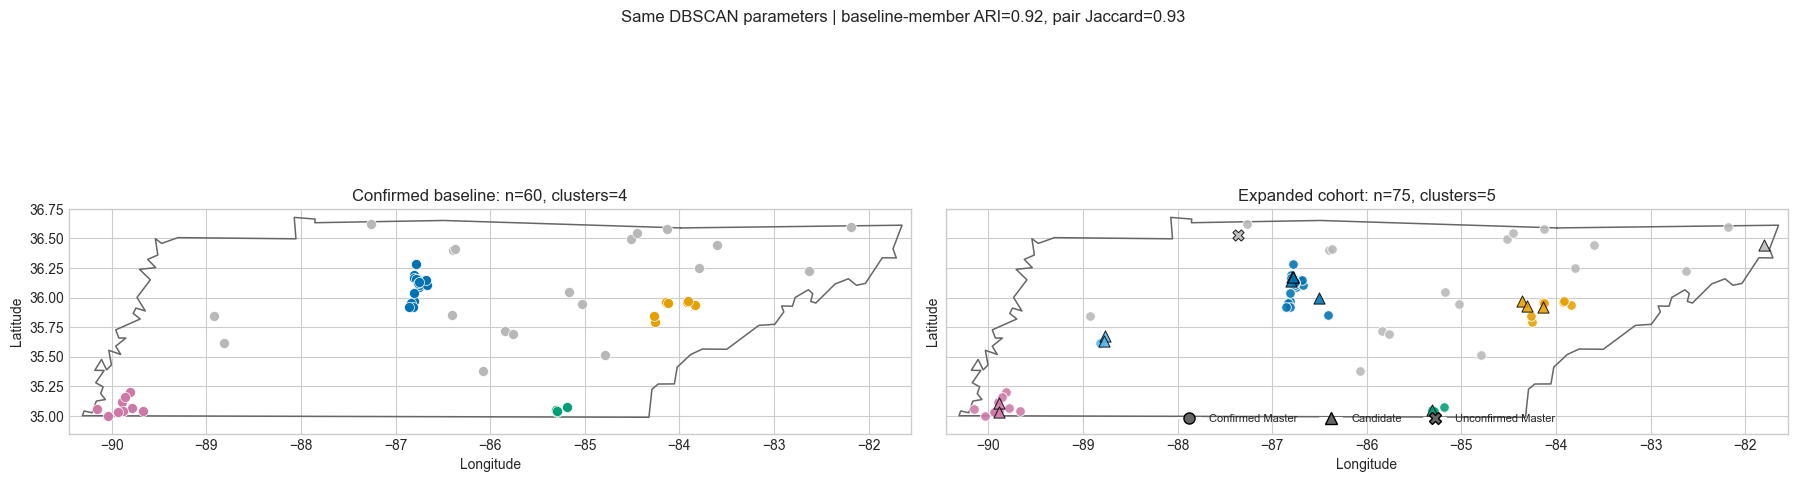

In [28]:
Dexp = distance_km(expanded_xy)
np.fill_diagonal(Dexp, np.inf)
expanded['expanded_nearest_neighbor_km'] = Dexp.min(axis=1)

geo_comparison = pd.DataFrame([
    {'cohort': 'Confirmed baseline', 'n': len(confirmed), 'clusters': len(set(primary) - {-1}),
     'clustered_n': int((primary >= 0).sum()), 'clustered_share': (primary >= 0).mean(),
     'noise_n': int((primary < 0).sum())},
    {'cohort': 'Expanded unique locations', 'n': len(expanded), 'clusters': len(set(expanded_raw) - {-1}),
     'clustered_n': int((expanded_raw >= 0).sum()), 'clustered_share': (expanded_raw >= 0).mean(),
     'noise_n': int((expanded_raw < 0).sum())}
])
display(geo_comparison.round(3))

comparison_ari = adjusted_rand_score(primary, expanded_baseline_labels)
comparison_jaccard = pair_jaccard(primary, expanded_baseline_labels)
candidate_cluster_rate = expanded.loc[expanded.record_role.eq('candidate'), 'geo_cluster_raw'].ge(0).mean()
confirmed_expanded_rate = expanded.loc[expanded.record_role.eq('confirmed_master'), 'geo_cluster_raw'].ge(0).mean()
expanded_geo_summary = (expanded[expanded.geo_cluster_raw >= 0].groupby('geo_cluster')
    .agg(n=('facility_id','size'), candidates=('record_role',lambda s: s.eq('candidate').sum()),
         confirmed=('record_role',lambda s: s.eq('confirmed_master').sum()),
         centroid_lat=('latitude','mean'), centroid_lon=('longitude','mean'),
         cities=('city','nunique'), median_nn_km=('expanded_nearest_neighbor_km','median'))
    .reset_index().sort_values('centroid_lon'))
display(expanded_geo_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 5.7), sharex=True, sharey=True)
draw_tn(axes[0])
for i, (name, g) in enumerate(confirmed.groupby('cluster', sort=False)):
    color = '#B8B8B8' if name == 'Noise / isolated' else COLORS[i % len(COLORS)]
    axes[0].scatter(g.longitude, g.latitude, s=52, color=color, edgecolor='white', linewidth=.5)
axes[0].set_title(f'Confirmed baseline: n=60, clusters={len(set(primary)-{-1})}')

draw_tn(axes[1])
geo_order = list(expanded['geo_cluster'].drop_duplicates())
geo_colors = {name: ('#B8B8B8' if name == 'Noise / isolated' else COLORS[i % len(COLORS)])
              for i, name in enumerate(geo_order)}
markers = {'confirmed_master': 'o', 'candidate': '^', 'unconfirmed_master': 'X'}
for (name, role), g in expanded.groupby(['geo_cluster', 'record_role'], sort=False):
    axes[1].scatter(g.longitude, g.latitude, s=65 if role != 'confirmed_master' else 48,
                    marker=markers[role], color=geo_colors[name], edgecolor='black' if role != 'confirmed_master' else 'white',
                    linewidth=.7, alpha=.88)
axes[1].set_title(f'Expanded cohort: n=75, clusters={len(set(expanded_raw)-{-1})}')
legend = [Line2D([0],[0], marker=m, color='w', label=r.replace('_',' ').title(), markerfacecolor='#666',
                 markeredgecolor='black', markersize=8) for r,m in markers.items()]
axes[1].legend(handles=legend, loc='lower center', ncol=3, fontsize=8)
fig.suptitle(f'Same DBSCAN parameters | baseline-member ARI={comparison_ari:.2f}, pair Jaccard={comparison_jaccard:.2f}', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / '12_baseline_vs_expanded_geography.png', dpi=200, bbox_inches='tight')
plt.show()

## 9 Characteristic cluster based on the site environment

Only 21 quantifiable external environment fields are used. District names, FIPS, disclosure tags, existing geographical cluster labels and nearest proximity do not participate in the preparation. The K value of KMeans is selected according to the highest silhouette score in group 2-8; PCA is used only for 2D displays and does not participate in the group.

,k,silhouette,inertia
0,2,0.388,796.411
1,3,0.380,614.005
2,4,0.354,532.542
3,5,0.243,467.835
4,6,0.253,416.161
5,7,0.260,373.113
6,8,0.276,344.999


,feature_cluster,n,candidates,confirmed,counties,median_total_employment,median_interstate_km,median_transmission_km
0,F1,20,3,16,14,14575.0,11.66,1.36
1,F2,55,11,44,9,446048.0,1.75,0.38


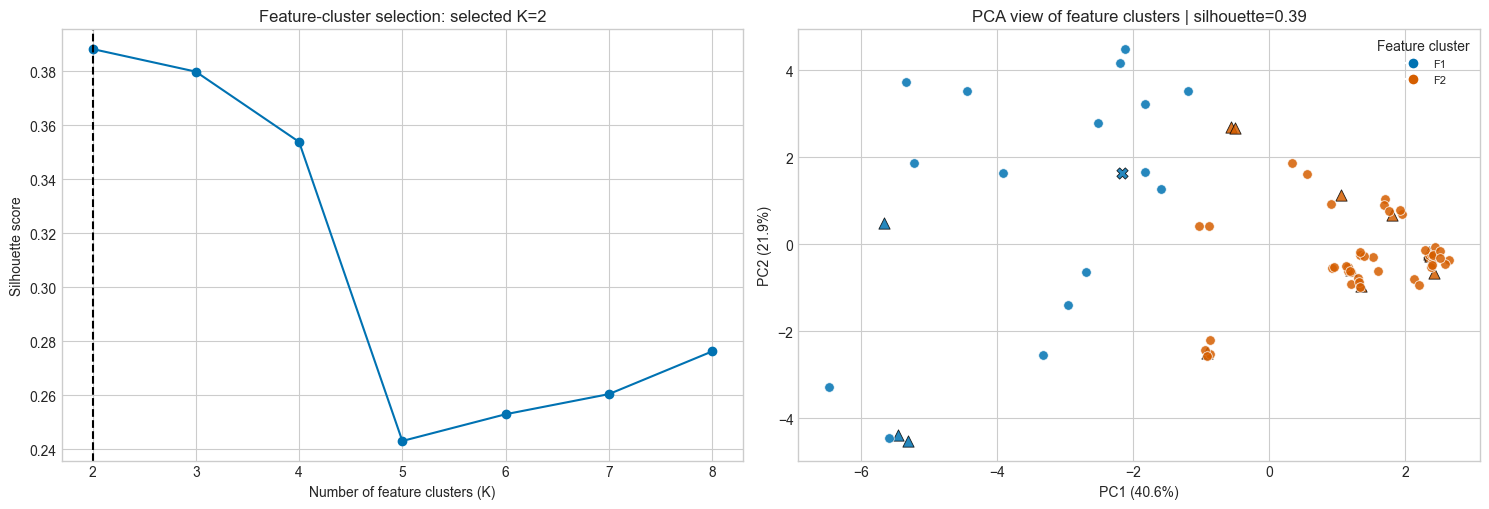

In [29]:
feature_cols = [
    'dist_transmission_any_km', 'dist_transmission_100kv_km', 'dist_transmission_230kv_km',
    'max_voltage_within_25km_kv', 'transmission_owner_count_25km',
    'dist_major_road_km', 'dist_interstate_km', 'dist_surface_water_flowline_km',
    'named_flowlines_within_25km', 'degree_institutions_50km', 'cip11_completions_50km',
    'cip14_completions_50km', 'degree_institutions_100km', 'cip11_completions_100km',
    'cip14_completions_100km', 'county_total_employment', 'county_total_establishments',
    'information_sector_employment', 'information_sector_establishments',
    'professional_scientific_employment', 'professional_scientific_establishments'
]
assert expanded[feature_cols].notna().all().all()
assert (expanded[feature_cols] >= 0).all().all()

X_log = np.log1p(expanded[feature_cols].astype(float))
scaler = RobustScaler()
X = scaler.fit_transform(X_log)

diagnostics = []
models = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X)
    models[k] = km
    diagnostics.append({'k': k, 'silhouette': silhouette_score(X, km.labels_), 'inertia': km.inertia_})
feature_diagnostics = pd.DataFrame(diagnostics)
best_k = int(feature_diagnostics.loc[feature_diagnostics.silhouette.idxmax(), 'k'])
feature_model = models[best_k]
raw_feature_labels = feature_model.labels_

# Stable labels ordered by median county employment, from smaller to larger markets.
employment_order = (pd.DataFrame({'raw': raw_feature_labels, 'employment': expanded.county_total_employment})
                    .groupby('raw').employment.median().sort_values().index)
feature_label_map = {raw: f'F{i+1}' for i, raw in enumerate(employment_order)}
expanded['feature_cluster'] = pd.Series(raw_feature_labels).map(feature_label_map).to_numpy()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
expanded['feature_pc1'] = coords[:, 0]
expanded['feature_pc2'] = coords[:, 1]
feature_silhouette = silhouette_score(X, raw_feature_labels)

feature_cluster_summary = (expanded.groupby('feature_cluster')
    .agg(n=('facility_id','size'), candidates=('record_role',lambda s: s.eq('candidate').sum()),
         confirmed=('record_role',lambda s: s.eq('confirmed_master').sum()),
         counties=('county','nunique'), median_total_employment=('county_total_employment','median'),
         median_interstate_km=('dist_interstate_km','median'),
         median_transmission_km=('dist_transmission_any_km','median'))
    .reset_index())
display(feature_diagnostics.round(3))
display(feature_cluster_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
axes[0].plot(feature_diagnostics.k, feature_diagnostics.silhouette, marker='o', color='#0072B2')
axes[0].axvline(best_k, color='black', ls='--')
axes[0].set(xlabel='Number of feature clusters (K)', ylabel='Silhouette score',
            title=f'Feature-cluster selection: selected K={best_k}')

feature_colors = {f'F{i+1}': COLORS[i % len(COLORS)] for i in range(best_k)}
for (fc, role), g in expanded.groupby(['feature_cluster', 'record_role'], sort=True):
    axes[1].scatter(g.feature_pc1, g.feature_pc2, color=feature_colors[fc], marker=markers[role],
                    s=66 if role != 'confirmed_master' else 48, edgecolor='black' if role != 'confirmed_master' else 'white',
                    linewidth=.6, alpha=.85)
axes[1].set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
            title=f'PCA view of feature clusters | silhouette={feature_silhouette:.2f}')
cluster_handles = [Line2D([0],[0], marker='o', color='w', label=f, markerfacecolor=c, markersize=8) for f,c in feature_colors.items()]
axes[1].legend(handles=cluster_handles, title='Feature cluster', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / '13_feature_cluster_selection_and_pca.png', dpi=190)
plt.show()

## 10 Characteristic group portraits and quantitative importance

`eta_squared` indicates the proportion of this feature that can be explained by the current group label. `silhouette_drop` indicates an average decrease (100 replacements) in the silhouette of a fixed group label after random disruption of a feature. The two measures the contribution of the cluster separation**, not the causal location effect.

,feature,eta_squared,silhouette_drop,silhouette_drop_sd
9,degree_institutions_50km,0.674,0.015,0.001
11,cip14_completions_50km,0.667,0.087,0.006
19,professional_scientific_employment,0.632,0.022,0.002
20,professional_scientific_establishments,0.630,0.020,0.001
16,county_total_establishments,0.605,0.019,0.001
18,information_sector_establishments,0.590,0.018,0.001
15,county_total_employment,0.583,0.022,0.002
17,information_sector_employment,0.559,0.027,0.003
10,cip11_completions_50km,0.432,0.020,0.002
6,dist_interstate_km,0.290,0.010,0.001


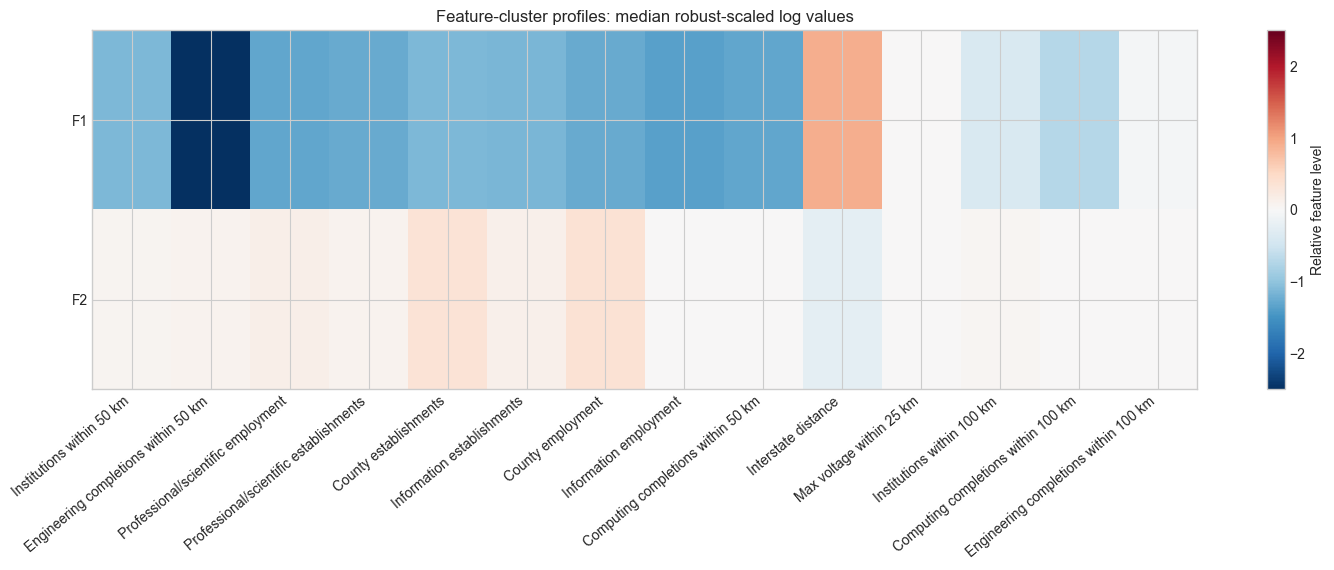

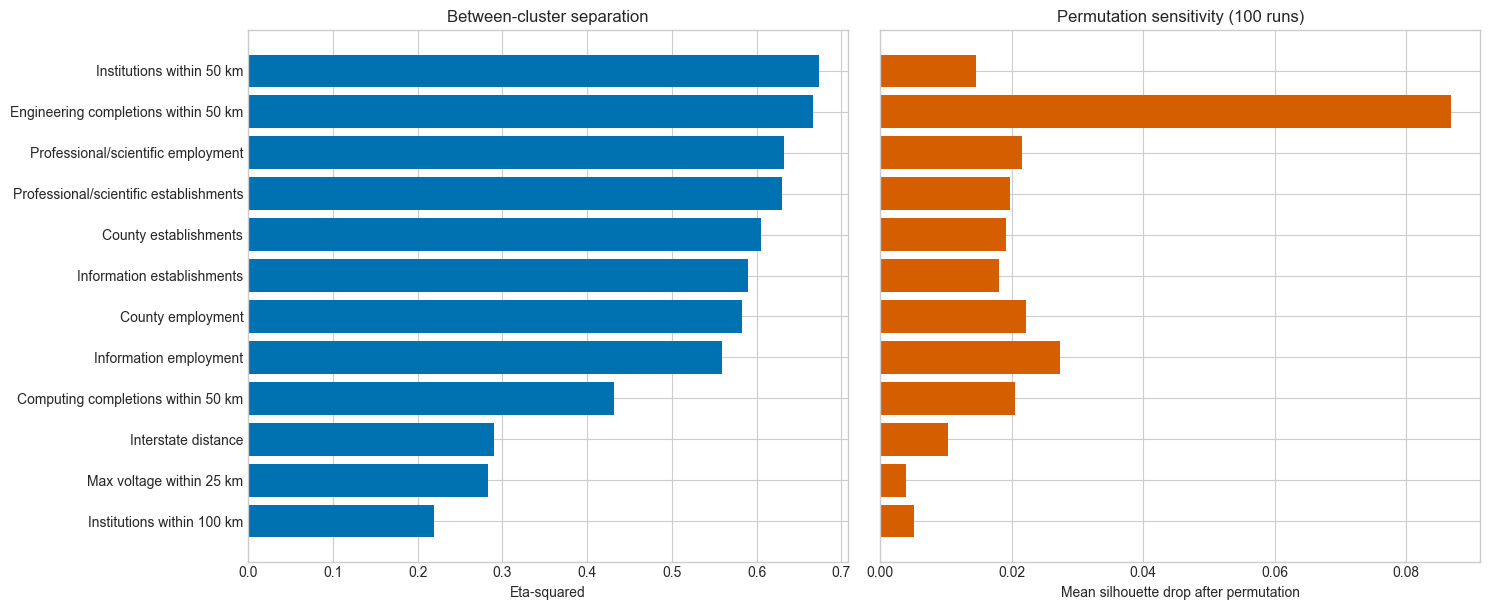

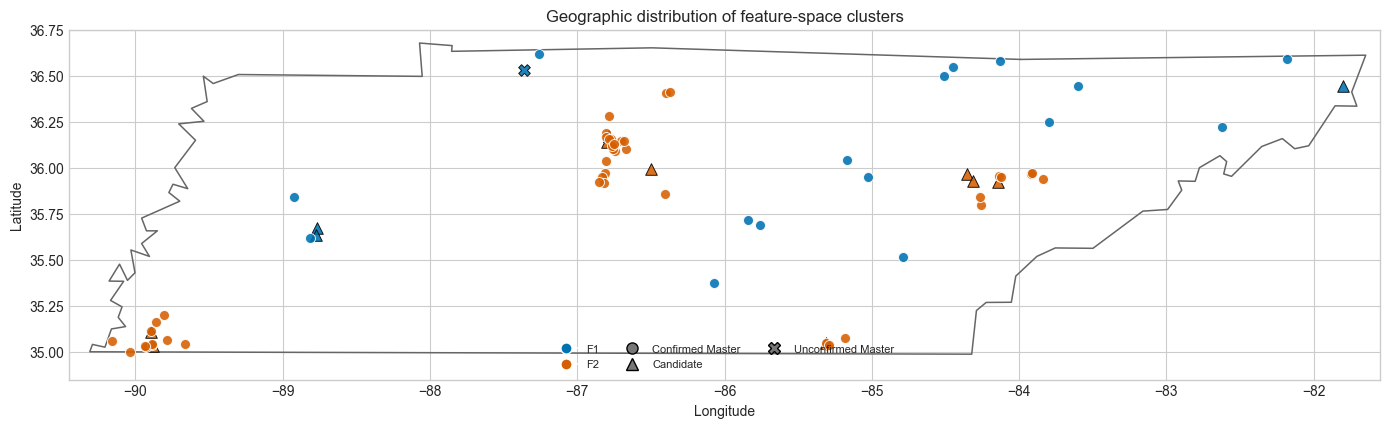

In [30]:
profile = pd.DataFrame(X, columns=feature_cols).assign(feature_cluster=expanded.feature_cluster).groupby('feature_cluster').median()

def eta_squared(values, labels):
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels)
    grand = values.mean()
    total = ((values - grand) ** 2).sum()
    between = sum((labels == g).sum() * (values[labels == g].mean() - grand) ** 2 for g in np.unique(labels))
    return float(between / total) if total else 0.0

rng_importance = np.random.default_rng(RANDOM_STATE)
importance_rows = []
for j, name in enumerate(feature_cols):
    shuffled_scores = []
    for _ in range(100):
        Xp = X.copy()
        Xp[:, j] = rng_importance.permutation(Xp[:, j])
        shuffled_scores.append(silhouette_score(Xp, raw_feature_labels))
    importance_rows.append({
        'feature': name,
        'eta_squared': eta_squared(X[:, j], raw_feature_labels),
        'silhouette_drop': feature_silhouette - float(np.mean(shuffled_scores)),
        'silhouette_drop_sd': float(np.std(shuffled_scores, ddof=1))
    })
feature_importance = pd.DataFrame(importance_rows).sort_values(['eta_squared', 'silhouette_drop'], ascending=False)
display(feature_importance.head(12).round(3))

short_names = {
    'dist_transmission_any_km':'Transmission distance', 'dist_transmission_100kv_km':'100 kV line distance',
    'dist_transmission_230kv_km':'230 kV line distance', 'max_voltage_within_25km_kv':'Max voltage within 25 km',
    'transmission_owner_count_25km':'Transmission owners within 25 km', 'dist_major_road_km':'Major-road distance',
    'dist_interstate_km':'Interstate distance', 'dist_surface_water_flowline_km':'Surface-water distance',
    'named_flowlines_within_25km':'Named flowlines within 25 km', 'degree_institutions_50km':'Institutions within 50 km',
    'cip11_completions_50km':'Computing completions within 50 km', 'cip14_completions_50km':'Engineering completions within 50 km',
    'degree_institutions_100km':'Institutions within 100 km', 'cip11_completions_100km':'Computing completions within 100 km',
    'cip14_completions_100km':'Engineering completions within 100 km', 'county_total_employment':'County employment',
    'county_total_establishments':'County establishments', 'information_sector_employment':'Information employment',
    'information_sector_establishments':'Information establishments',
    'professional_scientific_employment':'Professional/scientific employment',
    'professional_scientific_establishments':'Professional/scientific establishments'
}

fig, ax = plt.subplots(figsize=(15, 5.8))
shown = profile.loc[sorted(profile.index), feature_importance.head(14).feature]
im = ax.imshow(shown, cmap='RdBu_r', aspect='auto', vmin=-2.5, vmax=2.5)
ax.set_xticks(range(shown.shape[1]), [short_names[c] for c in shown.columns], rotation=40, ha='right')
ax.set_yticks(range(shown.shape[0]), shown.index)
ax.set_title('Feature-cluster profiles: median robust-scaled log values')
fig.colorbar(im, ax=ax, label='Relative feature level')
fig.tight_layout()
fig.savefig(FIGURES / '14_feature_cluster_profiles.png', dpi=190)
plt.show()

top = feature_importance.head(12).sort_values('eta_squared')
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), sharey=True)
axes[0].barh([short_names[x] for x in top.feature], top.eta_squared, color='#0072B2')
axes[0].set(xlabel='Eta-squared', title='Between-cluster separation')
axes[1].barh([short_names[x] for x in top.feature], top.silhouette_drop, color='#D55E00')
axes[1].set(xlabel='Mean silhouette drop after permutation', title='Permutation sensitivity (100 runs)')
fig.tight_layout()
fig.savefig(FIGURES / '15_feature_cluster_importance.png', dpi=190)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6.2))
draw_tn(ax)
for (fc, role), g in expanded.groupby(['feature_cluster', 'record_role'], sort=True):
    ax.scatter(g.longitude, g.latitude, color=feature_colors[fc], marker=markers[role],
               s=70 if role != 'confirmed_master' else 52, edgecolor='black' if role != 'confirmed_master' else 'white',
               linewidth=.7, alpha=.88)
handles = [Line2D([0],[0], marker='o', color='w', label=f, markerfacecolor=c, markersize=8) for f,c in feature_colors.items()]
handles += [Line2D([0],[0], marker=m, color='w', label=r.replace('_',' ').title(), markerfacecolor='#777', markeredgecolor='black', markersize=8) for r,m in markers.items()]
ax.legend(handles=handles, loc='lower center', ncol=max(3, best_k), fontsize=8)
ax.set_title('Geographic distribution of feature-space clusters')
fig.tight_layout()
fig.savefig(FIGURES / '16_feature_clusters_geography.png', dpi=200)
plt.show()

## 11. Offline interactive maps

Maps are embedded in all 75 unique locations, Tennessee borders and two cluster labels. Toggle geo-group or characterization group colour and filter by recording role. The file does not rely on CDN, map tiles or external CSV.

In [31]:
map_fields = ['facility_id','facility_name','city','county','facility_type','status_normalized','operator',
              'location_precision','location_confidence','longitude','latitude','record_role','geo_cluster','feature_cluster']
map_records = expanded[map_fields].where(pd.notna(expanded[map_fields]), None).to_dict('records')
state_rings = [ring.tolist() for ring in polygon_rings(tn['geometry'])]
all_colors = {'geo': geo_colors, 'feature': feature_colors}

html_doc = r"""<!doctype html><html><head><meta charset="utf-8"><title>TN DC clusters</title>
<style>body{font-family:system-ui,sans-serif;margin:0;background:#f5f7fa;color:#17212b}.wrap{max-width:1220px;margin:auto;padding:18px}
.card{background:white;border:1px solid #d7dde5;border-radius:12px;box-shadow:0 2px 10px #0001;padding:14px}.bar{display:flex;gap:14px;flex-wrap:wrap;align-items:center;margin:8px 0 12px}
button,select,label{font-size:14px}button,select{padding:6px 10px;border:1px solid #b8c2cc;border-radius:7px;background:white}
svg{width:100%;height:auto;background:#eef3f7;border-radius:8px;border:1px solid #ccd4dc}.state{fill:#fbfcfd;stroke:#46535f;stroke-width:1.8}.pt{cursor:pointer}.pt:hover{stroke:#111;stroke-width:2.8}
#detail{min-height:48px;padding:12px 4px 4px;font-size:14px;border-top:1px solid #e1e6eb;margin-top:10px}.muted{color:#66717d;font-size:13px}.legend{display:flex;gap:12px;flex-wrap:wrap;margin:8px 0}.sw{display:inline-block;width:11px;height:11px;border-radius:50%;margin-right:4px}#mapMethod{margin-top:12px;padding-top:10px;border-top:1px solid #e1e6eb}#clusterNotes{margin-top:10px;padding-top:12px;border-top:1px solid #e1e6eb;font-size:13px}.notegrid{display:grid;grid-template-columns:repeat(auto-fit,minmax(250px,1fr));gap:9px;margin-top:8px}.notegrid div{padding:8px 10px;border:1px solid #dfe5eb;border-radius:8px;background:#f8fafc}.notegrid b,.notegrid span{display:block}.notegrid span{margin-top:3px;color:#55616d}</style></head>
<body><div class="wrap"><h2>Tennessee data-center clusters — 75 unique locations</h2>
<div class="card"><div class="bar"><label>Color by <select id="mode"><option value="geo">Geographic cluster</option><option value="feature">Feature cluster</option></select></label><span id="roles"></span><button id="reset">Reset view</button></div><div id="legend" class="legend"></div><svg id="map" viewBox="0 0 1100 500" role="img" aria-label="Tennessee data-center cluster map"></svg><div id="detail"><strong>Select a point:</strong> click any marker to open its record. The detail line identifies the <b>site</b> and <b>city</b>; <b>record role</b> (confirmed Master, Candidate, or unconfirmed Master); <b>geographic cluster</b> from the DBSCAN map; <b>feature cluster</b> from the 21-feature K-means grouping; <b>facility type</b>; <b>status</b>; and <b>coordinate precision</b>. Selecting a point only opens details; it does not change its cluster assignment.</div><div id="clusterNotes" aria-live="polite"></div><div id="mapMethod" class="muted">Geographic mode: DBSCAN 20 km / min_samples 3. Feature mode: log1p + RobustScaler + KMeans. Triangles are Candidate records; crosses are unconfirmed Master records.</div></div></div>
<script>const sites=__DATA__,rings=__RINGS__,colors=__COLORS__;const svg=document.getElementById('map'),NS='http://www.w3.org/2000/svg',W=1100,H=500,pad=35,b=[-90.45,-81.55,34.85,36.75];
const X=x=>pad+(x-b[0])/(b[1]-b[0])*(W-2*pad),Y=y=>H-pad-(y-b[2])/(b[3]-b[2])*(H-2*pad);function el(n,a,p=svg){const e=document.createElementNS(NS,n);for(const[k,v]of Object.entries(a||{}))e.setAttribute(k,v);p.appendChild(e);return e}
for(const r of rings)el('path',{class:'state',d:r.map((q,i)=>(i?'L':'M')+X(q[0]).toFixed(1)+','+Y(q[1]).toFixed(1)).join(' ')+' Z'});
const roles=[...new Set(sites.map(d=>d.record_role))],roleBox=document.getElementById('roles');for(const r of roles){const l=document.createElement('label'),c=document.createElement('input');c.type='checkbox';c.checked=true;c.dataset.role=r;c.onchange=draw;l.append(c,document.createTextNode(' '+r.replaceAll('_',' ')+' '));roleBox.appendChild(l)}
const clusterNotes={geo:[['E1 Memphis area','13 locations in the Memphis/Shelby concentration.'],['E2 Jackson area','3 locations in the Jackson/Madison concentration.'],['E3 Nashville area','25 locations in the Nashville-area concentration.'],['E4 Chattanooga area','5 locations in the Chattanooga/Hamilton concentration.'],['E5 Knoxville area','10 locations in the Knoxville-area concentration.'],['Noise / isolated','No DBSCAN group with at least three locations inside the 20 km neighborhood.']],feature:[['F1','20 locations with lower median employment and longer median proximity to interstate and transmission assets.'],['F2','55 locations with higher metropolitan employment, institutions, and professional/scientific activity.']]};function renderNotes(mode){const notes=document.getElementById('clusterNotes');notes.innerHTML='<strong>'+ (mode==='geo'?'Geographic-cluster guide':'Feature-cluster guide') +'</strong><div class="notegrid">'+clusterNotes[mode].map(([name,desc])=>'<div><b>'+name+'</b><span>'+desc+'</span></div>').join('')+'</div>'}
function triangle(x,y){return `${x},${y-8} ${x-7},${y+6} ${x+7},${y+6}`}function cross(x,y){return `M${x-6},${y-6}L${x+6},${y+6}M${x+6},${y-6}L${x-6},${y+6}`}
function draw(){svg.querySelectorAll('.pt').forEach(x=>x.remove());const mode=document.getElementById('mode').value,on=new Set([...document.querySelectorAll('#roles input:checked')].map(x=>x.dataset.role));for(const d of sites){if(!on.has(d.record_role))continue;const key=mode==='geo'?d.geo_cluster:d.feature_cluster,c=colors[mode][key]||'#999',x=X(d.longitude),y=Y(d.latitude);let p;if(d.record_role==='candidate')p=el('polygon',{class:'pt',points:triangle(x,y),fill:c,stroke:'#111','stroke-width':1.1});else if(d.record_role==='unconfirmed_master')p=el('path',{class:'pt',d:cross(x,y),fill:'none',stroke:c,'stroke-width':3});else p=el('circle',{class:'pt',cx:x,cy:y,r:6,fill:c,stroke:'white','stroke-width':1.1});const t=el('title',{},p);t.textContent=d.facility_name+' — '+key;p.addEventListener('pointerdown',e=>e.stopPropagation());p.addEventListener('click',e=>{e.stopPropagation();document.getElementById('detail').textContent=['Selected point','Site: '+d.facility_name,'City: '+d.city,'Record role: '+d.record_role,'Geographic cluster: '+d.geo_cluster,'Feature cluster: '+d.feature_cluster,'Facility type: '+d.facility_type,'Status: '+d.status_normalized,'Coordinate precision: '+d.location_precision].filter(Boolean).join(' | ')})}const keys=[...new Set(sites.map(d=>mode==='geo'?d.geo_cluster:d.feature_cluster))];document.getElementById('legend').innerHTML=keys.map(k=>`<span><i class="sw" style="background:${colors[mode][k]||'#999'}"></i>${k}</span>`).join('');renderNotes(mode)}
document.getElementById('mode').onchange=draw;document.getElementById('reset').onclick=()=>svg.setAttribute('viewBox','0 0 1100 500');let drag=null;svg.addEventListener('wheel',e=>{e.preventDefault();let v=svg.viewBox.baseVal,f=e.deltaY>0?1.15:.87,cx=v.x+v.width/2,cy=v.y+v.height/2;svg.setAttribute('viewBox',[cx-v.width*f/2,cy-v.height*f/2,v.width*f,v.height*f].join(' '))},{passive:false});svg.addEventListener('pointerdown',e=>{if(e.target.classList&&e.target.classList.contains('pt'))return;drag={x:e.clientX,y:e.clientY,v:[svg.viewBox.baseVal.x,svg.viewBox.baseVal.y,svg.viewBox.baseVal.width,svg.viewBox.baseVal.height]};svg.setPointerCapture(e.pointerId)});svg.addEventListener('pointermove',e=>{if(!drag)return;let r=svg.getBoundingClientRect(),dx=(e.clientX-drag.x)*drag.v[2]/r.width,dy=(e.clientY-drag.y)*drag.v[3]/r.height;svg.setAttribute('viewBox',[drag.v[0]-dx,drag.v[1]-dy,drag.v[2],drag.v[3]].join(' '))});svg.addEventListener('pointerup',()=>drag=null);draw();
</script></body></html>"""
html_doc = (html_doc.replace('__DATA__', json.dumps(map_records, ensure_ascii=False))
            .replace('__RINGS__', json.dumps(state_rings))
            .replace('__COLORS__', json.dumps(all_colors)))
(RESULTS / 'interactive_clusters.html').write_text(html_doc, encoding='utf-8')
print('Interactive map records:', len(map_records))

Interactive map records: 75


## Manual quantitative analysis

This section presents manual analysis conclusions, characterization contribution tables and graphs directly in Notebook and no separate reports are generated.

- ** Cliff's delta**: comparing the distribution of clusters and isolated points in confimed base;
- **eta-squared**: the current feature group can explain the proportion of a characteristic ' s standardized deviation;
- **permutation silhouette drop**: on average, how much has been reduced in the current grouping after disrupting a feature.

The latter two explanations are the contribution of the feature to the separation of the currently non-oversight subgroups and do not represent the weight of the cause and effect of the location.

## Main findings

- In the confirmed baseline, 41/60 locations enter four geographical groups;
- In the 75-location expansion, 56/75 locations enter five geographical groups;
- The baseline locations retain an adjusted Rand index of **0.92** and a pairwise Jaccard score of **0.93** in the expanded cohort;
- KMeans selected **K=2** feature clusters with a silhouette score of **0.388**.

F1 Closer to the smaller job market, the more distant from the Interstate and power lines; F2 closer to the urban-type job market and the more accessible environments of transport and transmission.

## The contribution of features to the current group separation

,feature,eta_squared,mean_permutation_silhouette_drop,permutation_drop_sd
9,Institutions within 50 km,0.674,0.015,0.001
11,Engineering completions within 50 km,0.667,0.087,0.006
19,Professional/scientific employment,0.632,0.022,0.002
20,Professional/scientific establishments,0.630,0.020,0.001
16,County establishments,0.605,0.019,0.001
18,Information establishments,0.590,0.018,0.001
15,County employment,0.583,0.022,0.002
17,Information employment,0.559,0.027,0.003
10,Computing completions within 50 km,0.432,0.020,0.002
6,Interstate distance,0.290,0.010,0.001


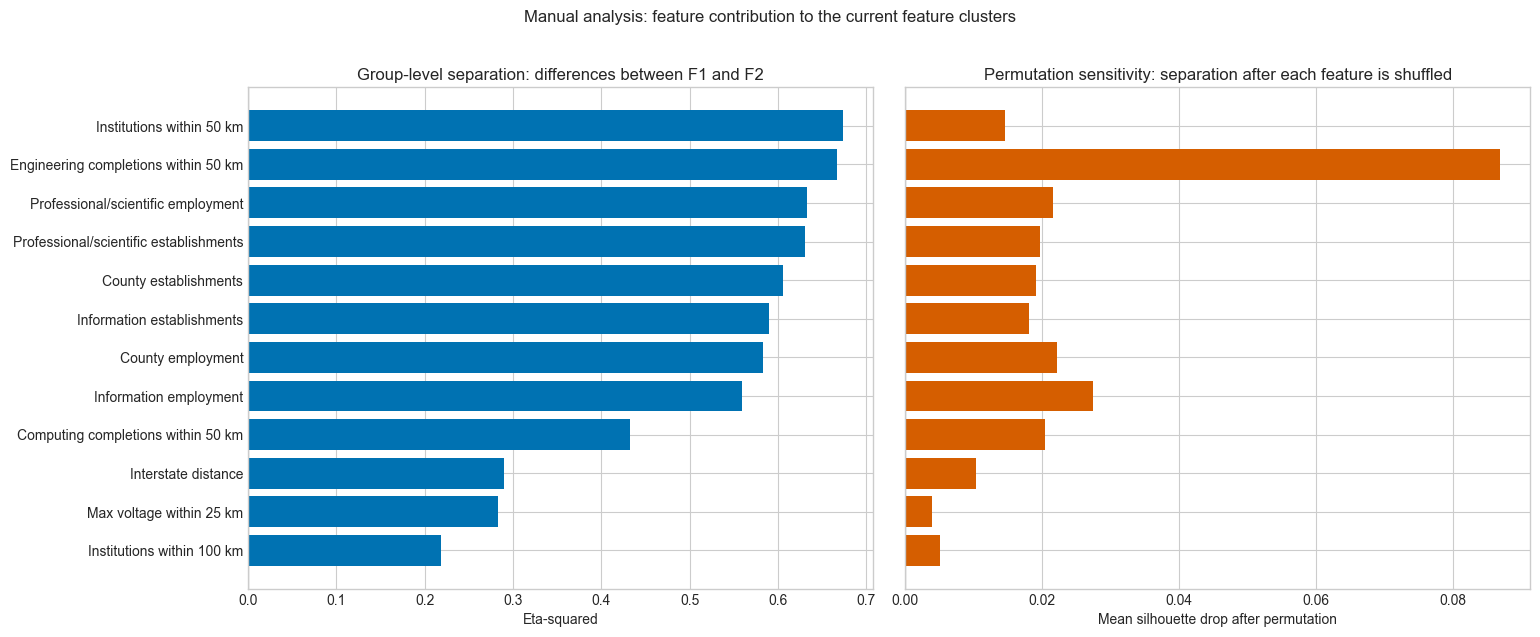

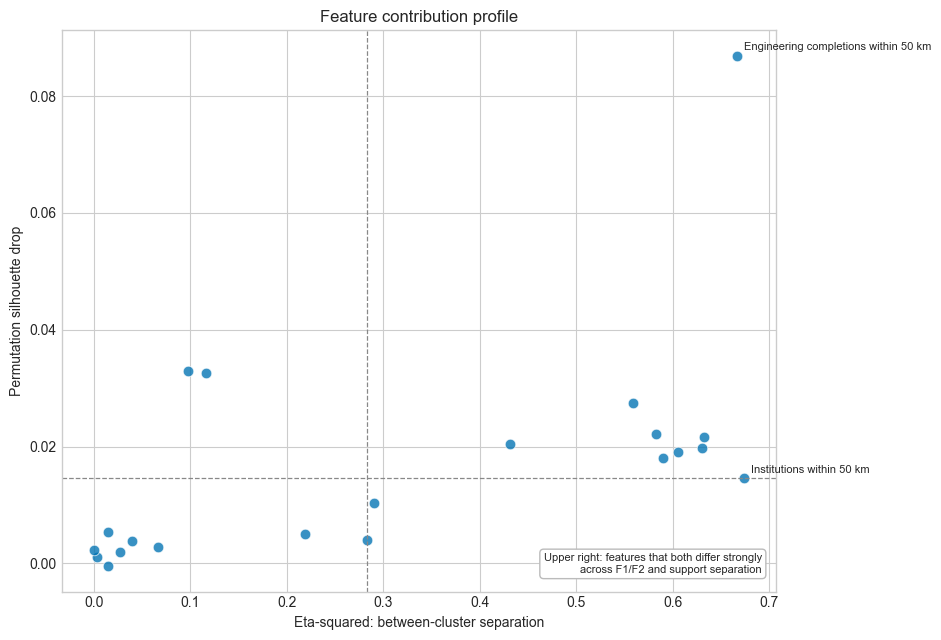

## Confirmed descriptive differences between grouped and isolated points

,feature,clustered_median,isolated_median,cliffs_delta
1,Information employment,4823.000,196.000,0.964
2,Professional/scientific employment,20108.000,364.000,0.959
0,County employment,446048.000,16494.000,0.949
3,Interstate distance,1.480,16.369,-0.743
4,Transmission distance,0.358,1.708,-0.448
5,Named flowlines within 25 km,1127.000,930.000,0.363
6,Institutions within 100 km,36.000,31.000,0.347
8,Major-road distance,0.266,0.494,-0.053
7,Surface-water distance,0.402,0.337,0.042


## Read the border

TNCAND-006 uses Nashville-Davison city representation points, which can only be used for market-level approximation. The results describe existing projects and the environmental clusters of candidate projects; to estimate the impact of a given factor on future sites, it is still necessary to add to the Phaase 2 possible background point and to conduct space validation.

In [32]:
def cliffs_delta(a, b):
    a = np.asarray(pd.Series(a).dropna(), dtype=float)
    b = np.asarray(pd.Series(b).dropna(), dtype=float)
    return float((np.greater.outer(a, b).sum() - np.less.outer(a, b).sum()) / (len(a) * len(b)))

baseline_features = expanded.set_index('facility_id').loc[confirmed.facility_id].reset_index()
baseline_features['baseline_clustered'] = primary >= 0
manual_features = [
    'county_total_employment', 'information_sector_employment',
    'professional_scientific_employment', 'dist_interstate_km',
    'dist_transmission_any_km', 'named_flowlines_within_25km',
    'degree_institutions_100km', 'dist_surface_water_flowline_km',
    'dist_major_road_km'
]
manual_rows = []
for f in manual_features:
    clustered_values = baseline_features.loc[baseline_features.baseline_clustered, f]
    isolated_values = baseline_features.loc[~baseline_features.baseline_clustered, f]
    manual_rows.append({
        'feature': f,
        'clustered_median': clustered_values.median(),
        'isolated_median': isolated_values.median(),
        'cliffs_delta': cliffs_delta(clustered_values, isolated_values)
    })
manual_effects = pd.DataFrame(manual_rows).sort_values(
    'cliffs_delta', key=lambda s: s.abs(), ascending=False
)
top_imp = feature_importance.head(12).copy()
top_imp['display_name'] = top_imp['feature'].map(short_names)

display(Markdown(
    f"""## Main findings

- In the confirmed baseline, {int((primary >= 0).sum())}/60 locations enter four geographical groups;
- In the 75-location expansion, {int((expanded_raw >= 0).sum())}/75 locations enter five geographical groups;
- The baseline locations retain an adjusted Rand index of **{comparison_ari:.2f}** and a pairwise Jaccard score of **{comparison_jaccard:.2f}** in the expanded cohort;
- KMeans selected **K={best_k}** feature clusters with a silhouette score of **{feature_silhouette:.3f}**.

F1 Closer to the smaller job market, the more distant from the Interstate and power lines; F2 closer to the urban-type job market and the more accessible environments of transport and transmission."""
))

display(Markdown('## The contribution of features to the current group separation'))
display(top_imp[['display_name', 'eta_squared', 'silhouette_drop', 'silhouette_drop_sd']].rename(columns={
    'display_name': 'feature',
    'silhouette_drop': 'mean_permutation_silhouette_drop',
    'silhouette_drop_sd': 'permutation_drop_sd'
}).round(3))

ranked = top_imp.sort_values('eta_squared')
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2), sharey=True)
axes[0].barh(ranked['display_name'], ranked['eta_squared'], color='#0072B2')
axes[0].set(
    xlabel='Eta-squared',
    title='Group-level separation: differences between F1 and F2'
)
axes[1].barh(ranked['display_name'], ranked['silhouette_drop'], color='#D55E00')
axes[1].set(
    xlabel='Mean silhouette drop after permutation',
    title='Permutation sensitivity: separation after each feature is shuffled'
)
for ax in axes:
    ax.axvline(0, color='#555555', lw=.8)
fig.suptitle('Manual analysis: feature contribution to the current feature clusters', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / '17_manual_feature_importance_ranking.png', dpi=200, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.scatter(
    feature_importance['eta_squared'],
    feature_importance['silhouette_drop'],
    s=58, color='#0072B2', alpha=.78, edgecolor='white', linewidth=.6
)
annotated_features = set(feature_importance.nlargest(2, 'eta_squared')['feature'])
annotated_features |= set(feature_importance.nlargest(1, 'silhouette_drop')['feature'])
for _, row in feature_importance[feature_importance['feature'].isin(annotated_features)].iterrows():
    ax.annotate(
        short_names[row['feature']],
        (row['eta_squared'], row['silhouette_drop']),
        xytext=(5, 4), textcoords='offset points', fontsize=8
    )
ax.axvline(feature_importance['eta_squared'].median(), color='#888888', ls='--', lw=.9)
ax.axhline(feature_importance['silhouette_drop'].median(), color='#888888', ls='--', lw=.9)
ax.set(
    xlabel='Eta-squared: between-cluster separation',
    ylabel='Permutation silhouette drop',
    title='Feature contribution profile'
)
ax.text(
    .98, .03,
    'Upper right: features that both differ strongly\nacross F1/F2 and support separation',
    transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
    bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '#bbbbbb'}
)
fig.tight_layout()
fig.savefig(FIGURES / '18_manual_feature_importance_profile.png', dpi=200, bbox_inches='tight')
plt.show()

display(Markdown('## Confirmed descriptive differences between grouped and isolated points'))
manual_display = manual_effects.copy()
manual_display['feature'] = manual_display['feature'].map(short_names)
display(manual_display.round(3))

display(Markdown(
    """## Read the border

TNCAND-006 uses Nashville-Davison city representation points, which can only be used for market-level approximation. The results describe existing projects and the environmental clusters of candidate projects; to estimate the impact of a given factor on future sites, it is still necessary to add to the Phaase 2 possible background point and to conduct space validation."""
))

## 13 Export Results with QA

In [33]:
export_cols = ['facility_id','facility_name','operator','city','county','latitude','longitude','location_precision',
               'location_confidence','status_normalized','facility_type','analysis_scope','nearest_neighbor_km','cluster']
confirmed[export_cols].to_csv(RESULTS / 'cluster_assignments.csv', index=False)
cluster_summary.to_csv(RESULTS / 'cluster_summary.csv', index=False)
sweep.to_csv(RESULTS / 'parameter_sweep.csv', index=False)
stability.to_csv(RESULTS / 'stability_summary.csv', index=False)
jitter.to_csv(RESULTS / 'coordinate_jitter_simulations.csv', index=False)
geo_comparison.to_csv(RESULTS / 'geographic_cohort_comparison.csv', index=False)
expanded.to_csv(RESULTS / 'expanded_cluster_assignments.csv', index=False)
expanded_geo_summary.to_csv(RESULTS / 'expanded_cluster_summary.csv', index=False)
feature_diagnostics.to_csv(RESULTS / 'feature_cluster_diagnostics.csv', index=False)
feature_cluster_summary.to_csv(RESULTS / 'feature_cluster_summary.csv', index=False)
feature_importance.to_csv(RESULTS / 'feature_cluster_importance.csv', index=False)
profile.to_csv(RESULTS / 'feature_cluster_profiles.csv')

required = [
    'cluster_assignments.csv','cluster_summary.csv','parameter_sweep.csv','stability_summary.csv',
    'coordinate_jitter_simulations.csv','geographic_cohort_comparison.csv','expanded_cluster_assignments.csv',
    'expanded_cluster_summary.csv',
    'feature_cluster_diagnostics.csv','feature_cluster_summary.csv','feature_cluster_importance.csv',
    'feature_cluster_profiles.csv','interactive_clusters.html'
]
checks = {
    'confirmed_rows_60': len(confirmed) == 60,
    'expanded_unique_rows_75': len(expanded) == 75 and expanded.facility_id.is_unique,
    'expanded_coordinates_complete': expanded[['latitude','longitude']].notna().all().all(),
    'feature_values_complete': expanded[feature_cols].notna().all().all(),
    'baseline_labels_complete': confirmed.cluster.notna().all(),
    'expanded_labels_complete': expanded[['geo_cluster','feature_cluster']].notna().all().all(),
    'all_exports_exist': all((RESULTS / f).exists() for f in required),
    'eighteen_static_figures': len(list(FIGURES.glob('*.png'))) >= 18,
    'interactive_map_has_75_records': len(map_records) == 75,
}
display(pd.Series(checks, name='passed').to_frame())
assert all(checks.values()), checks
print(f'QA passed: {sum(checks.values())}/{len(checks)} checks; selected feature K={best_k}; silhouette={feature_silhouette:.3f}')

,passed
confirmed_rows_60,True
expanded_unique_rows_75,True
expanded_coordinates_complete,True
feature_values_complete,True
baseline_labels_complete,True
expanded_labels_complete,True
all_exports_exist,True
eighteen_static_figures,True
interactive_map_has_75_records,True


QA passed: 9/9 checks; selected feature K=2; silhouette=0.388


## 14 Freeze subsequent modelling cohort and weight scenarios

Primary used only 60 confird Masters. Candidate insert in a separate weighted sensitivity scenario; Strict further excludes `area_or_city` coordinates. Numerical weights are kept at `weights/`, and records exclude and preserve with sole physical site processing at `results/`.

In [34]:
WEIGHTS = HERE / 'weights'
WEIGHTS.mkdir(parents=True, exist_ok=True)
candidate_source = pd.read_excel(SOURCE_XLSX, sheet_name='Candidate_Sites')
cohort_sites = pd.read_csv(FEATURE_MATRIX).rename(columns={'facility_id': 'site_id'})
cohort_sites['record_role'] = np.select(
    [cohort_sites.site_id.str.startswith('TNCAND-'), cohort_sites.analysis_scope.eq('unconfirmed_candidate')],
    ['candidate', 'unconfirmed_master'], default='confirmed_master'
)

primary_cohort = cohort_sites.loc[cohort_sites.record_role.eq('confirmed_master')].copy()
primary_cohort.insert(1, 'cohort', 'primary')
primary_cohort.to_csv(RESULTS / 'primary_presence_cohort.csv', index=False)

candidate_meta = candidate_source.set_index('candidate_id')
candidate_sites = cohort_sites.loc[cohort_sites.record_role.eq('candidate')].copy()
candidate_sites['candidate_type'] = candidate_sites.site_id.map(candidate_meta.candidate_type)
candidate_sites['candidate_confidence'] = candidate_sites.site_id.map(candidate_meta.candidate_confidence)
register_cols = ['site_id','facility_name','record_role','candidate_type','candidate_confidence',
                 'location_precision','location_confidence']
master_register = primary_cohort.copy()
master_register['candidate_type'] = pd.NA
master_register['candidate_confidence'] = pd.NA
weight_register = pd.concat([master_register[register_cols], candidate_sites[register_cols]], ignore_index=True)

candidate_weights = {'high': 0.75, 'medium': 0.50, 'low': 0.25}
is_candidate = weight_register.record_role.eq('candidate')
weight_register['primary_weight'] = np.where(is_candidate, 0.0, 1.0)
weight_register['weighted_weight'] = np.where(
    is_candidate, weight_register.candidate_confidence.map(candidate_weights), 1.0
)
weight_register['strict_weight'] = weight_register.weighted_weight
weight_register.loc[weight_register.location_precision.eq('area_or_city'), 'strict_weight'] = 0.0
weight_register['weight_basis'] = np.where(is_candidate, 'Candidate evidence confidence', 'confirmed Master')
weight_register.to_csv(WEIGHTS / 'presence_weights.csv', index=False)

def summarize_scenario(name, column, inclusion_rule, coordinate_rule):
    included = weight_register[column].gt(0)
    return {
        'scenario': name, 'included_n': int(included.sum()),
        'master_n': int((included & weight_register.record_role.eq('confirmed_master')).sum()),
        'candidate_n': int((included & is_candidate).sum()),
        'total_weight': weight_register[column].sum(),
        'inclusion_rule': inclusion_rule, 'coordinate_rule': coordinate_rule,
    }

scenarios = pd.DataFrame([
    summarize_scenario('primary', 'primary_weight', 'confirmed, mappable Master records',
                       'current confirmed Master coordinates'),
    summarize_scenario('weighted', 'weighted_weight', 'primary cohort plus unique Candidate locations',
                       'all current mapped locations'),
    summarize_scenario('strict', 'strict_weight', 'weighted cohort excluding area-or-city coordinates',
                       'location_precision is not area_or_city'),
])
scenarios.to_csv(WEIGHTS / 'cohort_sensitivity_scenarios.csv', index=False)

unique_candidate_ids = set(candidate_sites.site_id)
audit_rows = [{
    'record_id': 'TNDC-006', 'record_role': 'unconfirmed_master', 'representative_site_id': '',
    'primary_status': 'excluded', 'candidate_augmented_status': 'excluded', 'strict_status': 'excluded',
    'reason': 'project confirmation unresolved; area-or-city coordinate retained for audit only',
}]
for row in candidate_source.itertuples(index=False):
    if row.candidate_id == 'TNCAND-010':
        representative, augmented, strict = 'TNCAND-009', 'excluded', 'excluded'
        reason = 'shared ORNL physical site; represented once by TNCAND-009'
    elif pd.notna(row.master_facility_id):
        representative, augmented, strict = str(row.master_facility_id), 'excluded', 'excluded'
        reason = 'linked supporting evidence for an existing Master site'
    elif row.candidate_id in unique_candidate_ids:
        representative, augmented = row.candidate_id, 'included'
        strict = 'excluded' if row.location_precision == 'area_or_city' else 'included'
        reason = ('city representative coordinate; retained only in weighted sensitivity'
                  if strict == 'excluded' else 'unique mapped Candidate location')
    else:
        representative, augmented, strict = '', 'excluded', 'excluded'
        reason = 'not present in the deduplicated site feature matrix'
    audit_rows.append({
        'record_id': row.candidate_id, 'record_role': 'candidate',
        'representative_site_id': representative, 'primary_status': 'excluded',
        'candidate_augmented_status': augmented, 'strict_status': strict, 'reason': reason,
    })
cohort_audit = pd.DataFrame(audit_rows)
cohort_audit.to_csv(RESULTS / 'cohort_exclusion_audit.csv', index=False)

expected_candidates = set(candidate_source.candidate_id) - {'TNCAND-010', 'TNCAND-012'}
assert len(primary_cohort) == 60 and primary_cohort.site_id.is_unique
assert set(candidate_sites.site_id) == expected_candidates
assert len(weight_register) == 74 and weight_register.site_id.is_unique
assert scenarios.set_index('scenario').included_n.to_dict() == {'primary': 60, 'weighted': 74, 'strict': 73}
assert scenarios.set_index('scenario').total_weight.to_dict() == {'primary': 60.0, 'weighted': 69.0, 'strict': 68.5}
print(scenarios.to_string(index=False))
print('Cohort QA passed: 60 primary sites; 74 weighted sites; 73 strict sites')

scenario  included_n  master_n  candidate_n  total_weight                                     inclusion_rule                        coordinate_rule
 primary          60        60            0          60.0                 confirmed, mappable Master records   current confirmed Master coordinates
weighted          74        60           14          69.0     primary cohort plus unique Candidate locations           all current mapped locations
  strict          73        60           13          68.5 weighted cohort excluding area-or-city coordinates location_precision is not area_or_city
Cohort QA passed: 60 primary sites; 74 weighted sites; 73 strict sites
